# 3D Quadrotor Obstacle Avoidance — CBF Policy Comparison

State `[px, py, pz, vx, vy, vz, φ, θ, ψ, p, q, r]`, control `[u_T, u_τx, u_τy, u_τz]`.
Single sphere obstacle at `(1.0, 0.0, 1.4)` with radius `0.4 m`, plus altitude
floor/ceiling and roll/pitch limits (7 safety constraints total).

Compares the following safety filters under persistent position-bias measurement
noise (analog of `dbint2d_cbf_compare.ipynb` for the 2D double integrator):

**Nominal · CBF · R-CBF-QP · Duality CBF · R-CBF (γ=0.2) · R-CBF (γ=1.0) · MR-CBF · NMR-CBF · PSHR-CBF**

GUARDIAN (HJ reachability + NNV) is skipped because the 12-D state space makes
the HJ grid intractable.


In [1]:
import importlib
import functools as ft
import pickle
import sys
from pathlib import Path
sys.path.insert(0, '../../src')

import flax.linen as nn
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.collections import LineCollection
import numpy as np
import optax

from jaxproxqp.jaxproxqp import JaxProxQP as _JaxProxQP
from jaxproxqp.qp_problems import QPModel as _QPModel

from mrncbf.utils.jax_utils import jax_default_x32
from mrncbf.qp.min_norm_cbf import min_norm_cbf, rcbf_qp_linear, compute_rcbf_gammas

# Shared primitives -- see scripts/quad3d/quad3d_quad.py
# import quad3d_quad
# importlib.reload(quad3d_quad)
from quad3d_quad import (
    UMAX, DT, T,
    ALPHA_HOCBF, ALPHA_HOCBF_BASE, ALPHA_HOCBF_OBS,
    ALPHA_QP, ALPHA_QP_BASE, ALPHA_QP_OBS, ALPHA_QP_VEC,
    STATE_EPS, EPS_MAX, NMR_WEIGHTS_DIR,
    NX, NU, NH, Z_HOVER, OBSTACLE,
    u_lb, u_ub,
    f, G, h_raw, B_hocbf, _cbf_ingredients,
    GOAL_MC, nom_pol_goto,
    PhiNet, phi_net,
    task,
)

jax_default_x32()

BASE_KEY        = jr.PRNGKey(0)
_mc_results_dir = Path(NMR_WEIGHTS_DIR) / 'mc_results'
print(f'nx={NX} nu={NU} nh={NH}  dt={DT}  T={T} (={T*DT:.0f}s)')
print(f'obstacle (cx,cy,cz,r) = {OBSTACLE}')
print(f'mc_results_dir = {_mc_results_dir}')
print(f'ALPHA_QP_VEC = {np.array(ALPHA_QP_VEC)}')

Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/nrober/.pyenv/versions/pncbf_gpu/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 197, in _version_check
    version = get_version()
RuntimeError: cuDNN not found.

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/nrober/.pyenv/versions/pncbf_gpu/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 614, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/nrober/.pyenv/versions/pncbf_gpu/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/nrober/.pyenv/versions/pncbf_gpu/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 233, in _check_cuda_versions
    cudnn_version = _version_check(
  File "/home/nrober/.pyenv/v

nx=12 nu=4 nh=7  dt=0.01  T=1000 (=10s)
obstacle (cx,cy,cz,r) = (0.0, 0.0, 1.5, 0.25)
mc_results_dir = /home/nrober/code/pncbf/pncbf/runs/nmr_cbf_quad3d/policies/obs0.00_0.00_1.50_r0.25/mc_results
ALPHA_QP_VEC = [3. 3. 3. 3. 3. 3. 3.]


## Dynamics and HOCBF

`f(x)` includes thrust-direction-dependent gravity compensation and full rigid-body
attitude kinematics.  `G(x)` couples thrust to body z-axis and torques to
angular accelerations.

`h_components` returns the 6 base constraints + 1 obstacle (`h > 0` ⇒ UNSAFE).
`handcbf_B = task.handcbf_B` returns the (h < 0 ⇒ safe) HOCBF: stopping-distance
barriers for the altitude floor/ceil + HOCBF (`ψ₁ = L_f h + α·h`) extensions
for the attitude and obstacle constraints.


In [2]:
# Dynamics + HOCBF are imported from `quad3d_quad`.
x_hover = jnp.array(task.eq_state())
print(f'h_raw(hover) max:   {float(h_raw(x_hover).max()):+.3f}  (< 0 = safe)')
print(f'B_hocbf(hover) max: {float(B_hocbf(x_hover).max()):+.3f}  (< 0 = safe)')

# Verify hover is an equilibrium under the goto-goal policy with goal=hover.
goal_at_hover = jnp.zeros(NX).at[task.PZ].set(Z_HOVER)
u_hover = nom_pol_goto(x_hover, goal_at_hover)
print(f'nom_pol_goto(hover→hover): {np.array(u_hover).round(4)}')


h_raw(hover) max:   +1.000  (< 0 = safe)
B_hocbf(hover) max: +nan  (< 0 = safe)
nom_pol_goto(hover→hover): [-0.  0. -0. -0.]


## Observation model and rollout infrastructure


In [3]:
def _box_bounds(xhat):
    lo = xhat - STATE_EPS
    hi = xhat + STATE_EPS
    # Optional: clip eps box to train_bounds() so the worst-case search stays in
    # the physically meaningful region.
    return lo, hi


def _make_rollout(step_fn, goal=GOAL_MC):
    """Return a @jax.jit rollout(x0, bias) → (xs, xhats) suitable for jax.vmap."""
    @jax.jit
    def rollout(x0, bias):
        def _scan_step(carry, step_idx):
            return step_fn(carry, step_idx, goal)
        _, (xs, xhats) = jax.lax.scan(_scan_step, (x0, bias), jnp.arange(T))
        return jnp.concatenate([x0[None], xs], axis=0), xhats
    return rollout


def proj_grad_max_box(scalar_fn, lo, hi, n_restarts, n_steps, lr, key):
    x0s = lo[None] + jr.uniform(key, (n_restarts, lo.shape[0])) * (hi - lo)
    def run_one(x0):
        def step(x, _):
            g = jax.grad(scalar_fn)(x)
            return jnp.clip(x + lr * g, lo, hi), None
        x_star, _ = jax.lax.scan(step, x0, None, length=n_steps)
        return scalar_fn(x_star), x_star
    vals, xs = jax.vmap(run_one)(x0s)
    best = jnp.argmax(vals)
    return vals[best], xs[best]


ts      = np.arange(T + 1) * DT
ts_ctrl = np.arange(T) * DT


## Nominal and CBF policies


In [4]:
def _nom_step(carry, step_idx, goal):
    x, bias = carry
    xhat = x + bias
    u = nom_pol_goto(xhat, goal)
    return (x + DT*(f(x) + G(x) @ u), bias), (x, xhat)

def _cbf_step(carry, step_idx, goal):
    x, bias = carry
    xhat = x + bias
    h_B = B_hocbf(xhat)
    J_B = jax.jacobian(B_hocbf)(xhat)
    u_nom = nom_pol_goto(xhat, goal)
    u, _, _ = min_norm_cbf(ALPHA_QP_VEC, u_lb, u_ub, h_B, J_B,
                            f(xhat), G(xhat), u_nom, relax_eps2=0.1)
    return (x + DT*(f(x) + G(x) @ u), bias), (x, xhat)

## R-CBF-QP

Note: the γ produced by `compute_rcbf_gammas` is **rescaled per-constraint** by
`1/max(||L_G B_i||, 1)` before being passed to the QP.  Without this rescaling
a single global γ tightens the attitude HOCBF by `O(γ × ||L_G ψ_1||²)` ≈ `O(γ × 10⁴)`
(since `TAU_MAX / IXX = 100`), forcing `u_τx = u_τy = 0` and killing all motion.
The dbint2d system doesn't suffer from this because `||L_G B||≈1` for every
constraint there.


In [5]:
N_RCBF_SAMPLES = 20


def _scale_gamma_per_constraint(gamma, h_LG):
    """Rescale a scalar (or (nh,)) γ to per-constraint γ_i = γ / max(||LG_i||, 1).

    Required for quad3d because ||LG ψ_1|| varies by ~200× across constraints
    (attitude ≈ 100 from TAU_MAX/IXX, obstacle ≈ 0.5).  Without this rescaling
    a single global γ tightens the attitude HOCBF h_rho to O(γ × 100²) and
    forces u_τx,u_τy = 0, killing all motion.
    """
    LG_norm = jnp.linalg.norm(h_LG, axis=-1)
    scale   = 1.0 / jnp.maximum(LG_norm, 1.0)
    return jnp.broadcast_to(jnp.asarray(gamma), LG_norm.shape) * scale


def _rcbf_step(carry, step_idx, goal):
    x, bias    = carry
    xhat       = x + bias
    samp_key   = jr.fold_in(BASE_KEY, step_idx)
    lo, hi     = _box_bounds(xhat)
    h_V_nom    = B_hocbf(xhat)
    hx_Vx_nom  = jax.jacobian(B_hocbf)(xhat)
    u_nom      = nom_pol_goto(xhat, goal)
    x_pert     = lo[None] + jr.uniform(samp_key, (N_RCBF_SAMPLES, NX)) * (hi - lo)
    h_V_pert   = jax.vmap(B_hocbf)(x_pert)
    hx_Vx_pert = jax.vmap(jax.jacobian(B_hocbf))(x_pert)
    f_pert     = jax.vmap(f)(x_pert)
    G_pert     = jax.vmap(G)(x_pert)
    u_nom_pert = jax.vmap(lambda xp: nom_pol_goto(xp, goal))(x_pert)
    gamma1, gamma2 = compute_rcbf_gammas(
        ALPHA_QP_VEC, u_lb, u_ub,
        h_V_nom, hx_Vx_nom, f(xhat), G(xhat), u_nom,
        h_V_pert, hx_Vx_pert, f_pert, G_pert, u_nom_pert, n_grid=50)
    # Per-constraint rescale (see note in _scale_gamma_per_constraint).
    h_LG = hx_Vx_nom @ G(xhat)
    g1   = _scale_gamma_per_constraint(gamma1, h_LG)
    g2   = _scale_gamma_per_constraint(gamma2, h_LG)
    u, _, _ = rcbf_qp_linear(ALPHA_QP_VEC, u_lb, u_ub, h_V_nom, hx_Vx_nom,
                              f(xhat), G(xhat), u_nom,
                              gamma1=g1, gamma2=g2, relax_eps2=0.1)
    return (x + DT*(f(x) + G(x) @ u), bias), (x, xhat)


## Duality CBF

Builds a polytope over-approximation of the (nu+1 = 5)-D image set
`{ [LGψ₁_i(x), Lfψ₁_i(x) + α·ψ₁_i(x)] : x ∈ uncertainty box }`
via random-direction support functions, then solves a QP using LP duality.

Generalised from the dbint2d S² (3-D image) version to S⁴ (5-D image, nu=4).


In [6]:
N_PLANES_DUAL = 24
_rng_dirs  = np.random.default_rng(0)
_raw_dirs  = _rng_dirs.standard_normal((N_PLANES_DUAL, NU + 1))
_DUAL_DIRS = (_raw_dirs / np.linalg.norm(_raw_dirs, axis=1, keepdims=True)).astype(np.float32)
# Repeat (constraint, direction) pairs for vmap over all NH * N_PLANES_DUAL
_IJ_CI   = jnp.repeat(jnp.arange(NH), N_PLANES_DUAL)
_IJ_DIRS = jnp.tile(jnp.array(_DUAL_DIRS), (NH, 1))


def _image_fn(x, alpha=ALPHA_HOCBF):
    h_B, Lf_B, LG_B = _cbf_ingredients(x, alpha)
    return jnp.concatenate([LG_B, (Lf_B + ALPHA_QP_VEC * h_B)[:, None]], axis=1)   # (nh, nu+1)


def _duality_cbf_qp_multi(C_poly_list, d_poly_list, u_nom, relax_eps=0.1, penalty=10.0):
    """Duality CBF QP for nh constraints, each with its own polytope.

    Variables  : z = [λ₁..λ_(nh*N), u₁..u_nu, r]
    Equality   : for each constraint i, C_poly[i].T @ λ_i = [u; 1]
    Inequality : for each constraint i, d_poly[i].T @ λ_i ≤ r
    """
    nh = C_poly_list.shape[0]   # number of constraints
    N  = C_poly_list.shape[1]   # planes per constraint
    nu = NU
    n  = nh * N + nu + 1

    H = jnp.zeros((n, n))
    for ii in range(nu):
        H = H.at[nh*N + ii, nh*N + ii].set(1.0)
    H = H.at[-1, -1].set(penalty)

    g = jnp.zeros(n)
    for ii in range(nu):
        g = g.at[nh*N + ii].set(-u_nom[ii])
    g = g.at[-1].set(penalty * relax_eps)

    # Equality block: stack (nu+1) equations per constraint
    A_eq = jnp.zeros((nh * (nu + 1), n))
    b_eq = jnp.zeros(nh * (nu + 1))
    for i in range(nh):
        row0 = i * (nu + 1)
        col0 = i * N
        A_eq = A_eq.at[row0:row0 + nu + 1, col0:col0 + N].set(C_poly_list[i].T)
        # subtract u from rows 0..nu-1 (since C.T λ = [u; 1])
        for ii in range(nu):
            A_eq = A_eq.at[row0 + ii, nh*N + ii].set(-1.0)
        b_eq = b_eq.at[row0 + nu].set(1.0)

    # Inequality block: d_i.T @ λ_i - r ≤ 0
    C_ineq = jnp.zeros((nh, n))
    for i in range(nh):
        C_ineq = C_ineq.at[i, i*N:(i+1)*N].set(d_poly_list[i])
        C_ineq = C_ineq.at[i, -1].set(-1.0)
    l_ineq = jnp.full((nh,), -1e8)
    u_ineq = jnp.zeros(nh)

    l_box = jnp.concatenate([jnp.zeros(nh * N), u_lb, jnp.array([-relax_eps])])
    u_box = jnp.concatenate([jnp.full(nh * N, 1e8), u_ub, jnp.array([1e8])])

    qp  = _QPModel(H, g, A_eq, C_ineq, b_eq, u_ineq, l_ineq, u_box, l_box)
    sol = _JaxProxQP(qp, _JaxProxQP.Settings.default()).solve()
    return sol.x[nh*N:nh*N + nu], sol.x[-1], sol


def _duality_step(carry, step_idx, goal):
    x, bias  = carry
    xhat     = x + bias
    lo, hi   = _box_bounds(xhat)
    u_nom    = nom_pol_goto(xhat, goal)
    opt_key  = jr.fold_in(BASE_KEY, step_idx)
    all_keys = jr.split(opt_key, NH * N_PLANES_DUAL)

    def _support_one(ci, d_vec, k_j):
        """max over uncertainty box of d_vec ⋅ image_fn(x)[ci]"""
        val, _ = proj_grad_max_box(
            lambda xi: d_vec @ _image_fn(xi)[ci], lo, hi,
            n_restarts=2, n_steps=15, lr=0.03, key=k_j)
        return val

    d_poly_flat = jax.vmap(_support_one)(_IJ_CI, _IJ_DIRS, all_keys)   # (NH*N,)
    d_poly_list = d_poly_flat.reshape(NH, N_PLANES_DUAL)
    C_poly_list = jnp.broadcast_to(jnp.array(_DUAL_DIRS),
                                    (NH, N_PLANES_DUAL, NU + 1))
    u, _, _ = _duality_cbf_qp_multi(C_poly_list, d_poly_list, u_nom)
    return (x + DT*(f(x) + G(x) @ u), bias), (x, xhat)


## R-CBF with fixed γ

Same per-constraint γ rescaling as R-CBF-QP — see note in that section.


In [7]:
def _make_rcbf_fixed_step(gamma_val):
    def _step(carry, step_idx, goal):
        x, bias   = carry
        xhat      = x + bias
        h_V_nom   = B_hocbf(xhat)
        hx_Vx_nom = jax.jacobian(B_hocbf)(xhat)
        u_nom     = nom_pol_goto(xhat, goal)
        # Per-constraint γ rescale by 1/max(||LG_i||, 1) — see _scale_gamma_per_constraint
        # in the R-CBF-QP cell. Required because attitude ||LG|| ≈ 100 vs obs ≈ 0.5.
        h_LG = hx_Vx_nom @ G(xhat)
        g1   = _scale_gamma_per_constraint(gamma_val, h_LG)
        g2   = _scale_gamma_per_constraint(gamma_val, h_LG)
        u, _, _   = rcbf_qp_linear(ALPHA_QP_VEC, u_lb, u_ub, h_V_nom, hx_Vx_nom,
                                    f(xhat), G(xhat), u_nom,
                                    gamma1=g1, gamma2=g2, relax_eps2=0.1)
        return (x + DT*(f(x) + G(x) @ u), bias), (x, xhat)
    return _step


## MR-CBF — Lipschitz tightening

Conservative Lipschitz-based tightening of the CBF barrier.  For all
$x \in [\hat x - \varepsilon, \hat x + \varepsilon]$:

$$L_f B(x) + L_G B(x)\,u + \alpha B(x)
  \;\le\;
  L_f B(\hat x) + L_G B(\hat x)\,u + \alpha B(\hat x)
  + \sum_i \varepsilon_i \bigl(L^{L_f B}_i + \alpha\,L^{B}_i\bigr)
  + \sum_i \varepsilon_i L^{L_G B}_i \cdot \|u\|_2$$

Bounding $\|u\|_2 \le \sqrt{n_u}\,u_{\max}$ gives a state-independent scalar
$\phi_{\rm MR}$.  Same as `dbint2d`, but `G(x)` here is **not** constant
(thrust direction depends on attitude), so this bound is genuinely
conservative — still solvable as a standard CBF-QP with a fixed-point
iteration on the ‖u‖₂ self-consistency.


In [8]:
# ── Per-dim Lipschitz constant estimation ────────────────────────────────────
# Estimates max |∂ B_i / ∂x_j|, |∂ Lf B_i / ∂x_j|, ||∂ LG B_i / ∂x_j||_2
# via finite differences over states in a wide flight envelope.

_X_LO_LIP = np.array([-2.5, -2.5, 0.3, -2., -2., -2., -0.3, -0.3, -0.5, -1., -1., -0.5])
_X_HI_LIP = np.array([ 2.5,  2.5, 2.8,  2.,  2.,  2.,  0.3,  0.3,  0.5,  1.,  1.,  0.5])


def _estimate_lipschitz_per_dim(n_samples=2000, delta=1e-3):
    rng     = np.random.default_rng(123)
    cands   = _X_LO_LIP + rng.random((n_samples, NX)) * (_X_HI_LIP - _X_LO_LIP)
    cx, cy, cz, r_obs = OBSTACLE
    dist    = np.sqrt((cands[:, 0]-cx)**2 + (cands[:, 1]-cy)**2 + (cands[:, 2]-cz)**2)
    outside = dist > (r_obs + 0.1)
    xs      = cands[outside]
    print(f'  using {len(xs)} samples ({outside.sum()}/{n_samples} outside obstacle)')

    @jax.jit
    def _ingredients(xi):
        h_B  = B_hocbf(xi)                  # (nh,)
        J_B  = jax.jacobian(B_hocbf)(xi)    # (nh, nx)
        Lf_B = J_B @ f(xi)                   # (nh,)
        LG_B = J_B @ G(xi)                   # (nh, nu)
        return jnp.concatenate([h_B, Lf_B, LG_B.ravel()])   # (nh + nh + nh*nu,)

    _vmap_ing = jax.jit(jax.vmap(_ingredients))
    vals = np.array(_vmap_ing(jnp.array(xs, dtype=jnp.float32)))   # (n, nh*(2+nu))

    L_B_dim  = np.zeros((NH, NX))
    L_Lf_dim = np.zeros((NH, NX))
    L_LG_dim = np.zeros((NH, NX))   # 2-norm over the nu output channels per (h, x_j)
    for j in range(NX):
        xs_p = xs.copy(); xs_p[:, j] += delta
        dv = np.abs(np.array(_vmap_ing(jnp.array(xs_p, dtype=jnp.float32)))
                    - vals) / delta              # (n, nh*(2+nu))
        # split
        h_part  = dv[:, :NH]                                    # (n, nh)
        Lf_part = dv[:, NH:2*NH]                                # (n, nh)
        LG_part = dv[:, 2*NH:].reshape(-1, NH, NU)              # (n, nh, nu)
        L_B_dim[:,  j] = h_part.max(axis=0)
        L_Lf_dim[:, j] = Lf_part.max(axis=0)
        L_LG_dim[:, j] = np.linalg.norm(LG_part, axis=2).max(axis=0)
    return L_B_dim, L_Lf_dim, L_LG_dim


print('Estimating Lipschitz constants (MR-CBF)...')
_L_B_dim, _L_Lf_dim, _L_LG_dim = _estimate_lipschitz_per_dim()
_L_ah_dim = ALPHA_QP_VEC[:, None] * _L_B_dim     # (nh, nx)

_eps_arr        = np.array(STATE_EPS)             # (nx,)
_tight_const_np = (_L_Lf_dim + _L_ah_dim) @ _eps_arr         # (nh,) constant term
_tight_LG_np    =  _L_LG_dim                  @ _eps_arr     # (nh,) coeff of ||u||_2

_TIGHT_CONST = jnp.asarray(_tight_const_np, dtype=jnp.float32)
_TIGHT_LG    = jnp.asarray(_tight_LG_np,    dtype=jnp.float32)

print(f'  max L_B  per dim:   {_L_B_dim.max(axis=0).round(3)}')
print(f'  max L_Lf per dim:   {_L_Lf_dim.max(axis=0).round(3)}')
print(f'  max L_LG per dim:   {_L_LG_dim.max(axis=0).round(3)}')
print(f'  tight_const (nh,):  {_tight_const_np.round(3)}')
print(f'  tight_LG    (nh,):  {_tight_LG_np.round(3)}')


Estimating Lipschitz constants (MR-CBF)...
  using 1990 samples (1990/2000 outside obstacle)
  max L_B  per dim:   [5.578 6.104 6.025 1.    0.999 0.991 2.308 2.    0.    1.    1.    0.309]
  max L_Lf per dim:   [26.383 25.588 22.596  7.443  8.968  9.635  9.804  9.803  3.803  2.293
  2.257  0.906]
  max L_LG per dim:   [13.218 10.551 24.359  0.     0.     1.    38.021 41.475  3.803  0.
  0.     0.   ]
  tight_const (nh,):  [ 0.772       0.75900006  1.3290001   1.3290001   1.097       1.097
 38.863003  ]
  tight_LG    (nh,):  [ 0.218  0.217  4.341  4.341  2.281  2.281 12.189]


In [9]:
def _mrcbf_step(carry, step_idx, goal):
    """Lipschitz MR-CBF (Dean et al. 2020 style).

    Constraint:
        Lf B(x̂) + LG B(x̂) u + α·B(x̂)  ≤  -tight_const - tight_LG · ||u||_2
    Strategy: fixed-point iteration on s = ||u||_2, since for fixed s this
    reduces to a standard CBF-QP with tightened barrier
      B_eff_i = B_i + (tight_const_i + tight_LG_i * s) / α.
    """
    x, bias = carry
    xhat    = x + bias
    h_B     = B_hocbf(xhat)
    J_B     = jax.jacobian(B_hocbf)(xhat)
    f_xh    = f(xhat)
    G_xh    = G(xhat)
    u_nom   = nom_pol_goto(xhat, goal)

    def qp_given_s(s):
        phi     = _TIGHT_CONST + _TIGHT_LG * s            # (nh,)
        h_tight = h_B + phi / ALPHA_QP_VEC                # tighten per-constraint
        u, _, _ = min_norm_cbf(ALPHA_QP_VEC, u_lb, u_ub, h_tight, J_B,
                               f_xh, G_xh, u_nom, relax_eps2=0.1)
        return u

    def body(s, _):
        u_s   = qp_given_s(s)
        s_new = jnp.linalg.norm(u_s)
        return 0.5 * s + 0.5 * s_new, None

    s0 = jnp.linalg.norm(u_nom)
    s_final, _ = jax.lax.scan(body, s0, None, length=8)
    u = qp_given_s(s_final)
    return (x + DT * (f(x) + G(x) @ u), bias), (x, xhat)


## NMR-CBF — Learning φ

For each constraint $i$:
$$\phi_i(\hat x, \varepsilon) \;\approx\;
  \max_{x \in [\hat x - \varepsilon,\, \hat x + \varepsilon]}
  \!\bigl[L_f\psi_{1,i}(x) + \alpha\,\psi_{1,i}(x)\bigr]
  - \bigl[L_f\psi_{1,i}(\hat x) + \alpha\,\psi_{1,i}(\hat x)\bigr]$$

Network input is `(x̂, ε)` concatenated — trains across `ε ~ Uniform[0, EPS_MAX]`
so the same weights generalise to any noise level up to `EPS_MAX`.
Weights cached at `NMR_WEIGHTS_DIR/phi_params.pkl`.


In [10]:
PHI_MAX = 10.0
N_NMR_ORACLE_RESTARTS = 4
N_NMR_ORACLE_STEPS    = 30


@ft.partial(jax.jit, static_argnames=('n_restarts', 'n_steps'))
def phi_true_fn(xhat, eps, key,
                n_restarts=N_NMR_ORACLE_RESTARTS, n_steps=N_NMR_ORACLE_STEPS, lr=0.03):
    """φ_i(x̂, ε) = max_{x∈box}(Lf ψ + α ψ)(x)_i − (Lf ψ + α ψ)(x̂)_i, clipped ≥ 0."""
    lo = xhat - eps
    hi = xhat + eps
    h_nom  = B_hocbf(xhat)
    Lf_nom = jax.jacobian(B_hocbf)(xhat) @ f(xhat)
    nom    = Lf_nom + ALPHA_QP_VEC * h_nom # (nh,)

    def worst_i(i, k):
        def obj(xi):
            h  = B_hocbf(xi)
            Lf = jax.jacobian(B_hocbf)(xi) @ f(xi)
            return (Lf + ALPHA_QP_VEC * h)[i]
        _, x_wc = proj_grad_max_box(obj, lo, hi, n_restarts, n_steps, lr, k)
        h_wc  = B_hocbf(x_wc)
        Lf_wc = jax.jacobian(B_hocbf)(x_wc) @ f(x_wc)
        delta = (Lf_wc + ALPHA_QP_VEC * h_wc)[i] - nom[i]
        return jnp.clip(delta, 0.0, PHI_MAX)

    keys = jr.split(key, NH)
    return jax.vmap(worst_i)(jnp.arange(NH), keys)


_nmr_dir           = Path(NMR_WEIGHTS_DIR)
_nmr_pretrain_file = _nmr_dir / 'phi_params.pkl'
_nmr_finetune_file = _nmr_dir / 'phi_params_finetune_rl_v1.pkl'

if _nmr_pretrain_file.exists():
    with open(_nmr_pretrain_file, 'rb') as _f:
        _phi_params_pretrain = pickle.load(_f)
    print(f'Loaded NMR-CBF (pretrain) weights from {_nmr_pretrain_file}')
else:
    _phi_params_pretrain = phi_net.init(jr.PRNGKey(0), jnp.zeros(NX), jnp.zeros(NX))['params']
    n_params   = sum(p.size for p in jax.tree_util.tree_leaves(_phi_params_pretrain))
    print(f'Training PhiNet ({n_params} params, input={2*NX}, output={NH})...')

    # Sample training states across a wide hover-friendly envelope.
    _phi_lb = jnp.array([-2., -2., 0.3, -2., -2., -2., -0.3, -0.3, -0.5, -1., -1., -0.5])
    _phi_ub = jnp.array([ 2.,  2., 2.8,  2.,  2.,  2.,  0.3,  0.3,  0.5,  1.,  1.,  0.5])

    N_TRAIN, N_TEST = 24000, 6000
    rng_phi = jr.PRNGKey(7)
    rng_phi, rng_tr, rng_te, rng_eps_tr, rng_eps_te = jr.split(rng_phi, 5)

    # Reject states inside the obstacle.
    cx, cy, cz, r_obs = OBSTACLE
    def _outside(xh):
        d2 = (xh[0] - cx)**2 + (xh[1] - cy)**2 + (xh[2] - cz)**2
        return d2 > (r_obs + 0.1) ** 2

    cands_tr = _phi_lb + jr.uniform(rng_tr, (N_TRAIN * 2, NX)) * (_phi_ub - _phi_lb)
    cands_te = _phi_lb + jr.uniform(rng_te, (N_TEST  * 2, NX)) * (_phi_ub - _phi_lb)
    xhat_train = cands_tr[jax.vmap(_outside)(cands_tr)][:N_TRAIN]
    xhat_test  = cands_te[jax.vmap(_outside)(cands_te)][:N_TEST]

    eps_train = jr.uniform(rng_eps_tr, (N_TRAIN, NX)) * EPS_MAX
    eps_test  = jr.uniform(rng_eps_te, (N_TEST,  NX)) * EPS_MAX

    keys_tr = jr.split(jr.PRNGKey(1), N_TRAIN)
    keys_te = jr.split(jr.PRNGKey(2), N_TEST)

    print('  Computing phi_true (training)...')
    phi_train = jax.vmap(phi_true_fn)(xhat_train, eps_train, keys_tr)
    print('  Computing phi_true (test)...')
    phi_test  = jax.vmap(phi_true_fn)(xhat_test,  eps_test,  keys_te)
    print(f'  phi: mean={float(jnp.mean(phi_train)):.4f}  '
          f'max={float(jnp.max(phi_train)):.4f}  min={float(jnp.min(phi_train)):.4f}')

    optimizer = optax.adam(3e-3)
    opt_state = optimizer.init(_phi_params_pretrain)

    @jax.jit
    def train_step(params, opt_state, xhat_b, eps_b, phi_b):
        def loss_fn(p):
            pred = jax.vmap(lambda x, e: phi_net.apply({'params': p}, x, e))(xhat_b, eps_b)
            return jnp.mean((pred - phi_b) ** 2)
        loss, grads = jax.value_and_grad(loss_fn)(params)
        updates, new_opt = optimizer.update(grads, opt_state, params)
        return optax.apply_updates(params, updates), new_opt, loss

    rng_ep = jr.PRNGKey(42)
    for epoch in range(300):
        rng_ep, rng_s = jr.split(rng_ep)
        perm = jr.permutation(rng_s, N_TRAIN)
        for b in range(0, N_TRAIN, 256):
            idx = perm[b : b + 256]
            _phi_params_pretrain, opt_state, ep_loss = train_step(
                _phi_params_pretrain, opt_state, xhat_train[idx], eps_train[idx], phi_train[idx])
        if (epoch + 1) % 50 == 0:
            pred_val = jax.vmap(lambda x, e: phi_net.apply({'params': _phi_params_pretrain}, x, e))(
                xhat_test, eps_test)
            val_mse = float(jnp.mean((pred_val - phi_test) ** 2))
            print(f'  Epoch {epoch+1:3d}  train_loss={ep_loss:.3e}  val_mse={val_mse:.3e}')

    _nmr_dir.mkdir(parents=True, exist_ok=True)
    with open(_nmr_pretrain_file, 'wb') as _f:
        pickle.dump(_phi_params_pretrain, _f)
    print(f'Saved NMR-CBF (pretrain) weights to {_nmr_pretrain_file}')

if _nmr_finetune_file.exists():
    with open(_nmr_finetune_file, 'rb') as _f:
        _phi_params_finetune = pickle.load(_f)
    print(f'Loaded NMR-CBF (RL) weights from {_nmr_finetune_file}')
else:
    _phi_params_finetune = None
    print(f'NMR-CBF (RL) weights not found at {_nmr_finetune_file} — will reuse pretrain weights')


Loaded NMR-CBF (pretrain) weights from /home/nrober/code/pncbf/pncbf/runs/nmr_cbf_quad3d/policies/obs0.00_0.00_1.50_r0.25/phi_params.pkl
Loaded NMR-CBF (RL) weights from /home/nrober/code/pncbf/pncbf/runs/nmr_cbf_quad3d/policies/obs0.00_0.00_1.50_r0.25/phi_params_finetune_rl_v1.pkl


In [11]:
def _make_nmr_step(phi_params_frozen):
    def _nmr_step(carry, step_idx, goal):
        x, bias   = carry
        xhat      = x + bias
        phi       = phi_net.apply({'params': phi_params_frozen}, xhat, STATE_EPS)
        h_B       = B_hocbf(xhat)
        J_B       = jax.jacobian(B_hocbf)(xhat)
        u_nom     = nom_pol_goto(xhat, goal)
        u, _, _   = min_norm_cbf(ALPHA_QP_VEC, u_lb, u_ub, h_B + phi/ALPHA_QP_VEC, J_B,
                                  f(xhat), G(xhat), u_nom, relax_eps2=0.1)
        return (x + DT*(f(x) + G(x) @ u), bias), (x, xhat)
    return _nmr_step


_nmr_pretrain_step = _make_nmr_step(_phi_params_pretrain)
_phi_rl            = _phi_params_finetune if _phi_params_finetune is not None else _phi_params_pretrain
_nmr_finetune_step = _make_nmr_step(_phi_rl)


## PSHR-CBF (φ-oracle) — worst-case Lf+αh, nominal LG

Like NMR-CBF but computes φ exactly at runtime via projected-gradient ascent
instead of using a learned network.  Slower; same accuracy as the oracle that
labels the NMR-CBF training data.


In [12]:
def _lfhwc_step(carry, step_idx, goal):
    x, bias   = carry
    xhat      = x + bias
    lo, hi    = _box_bounds(xhat)
    u_nom     = nom_pol_goto(xhat, goal)
    opt_key   = jr.fold_in(BASE_KEY, step_idx)

    h_nom  = B_hocbf(xhat)
    J_nom  = jax.jacobian(B_hocbf)(xhat)
    Lf_nom = J_nom @ f(xhat)

    keys = jr.split(opt_key, NH)

    def worst_i(i, k):
        _, x_wc = proj_grad_max_box(
            lambda xi: (jax.jacobian(B_hocbf)(xi) @ f(xi) + ALPHA_QP_VEC * B_hocbf(xi))[i],
            lo, hi, n_restarts=4, n_steps=25, lr=0.03, key=k)
        h_wc_i  = B_hocbf(x_wc)[i]
        Lf_wc_i = (jax.jacobian(B_hocbf)(x_wc) @ f(x_wc))[i]
        return h_wc_i, Lf_wc_i

    h_wc, Lf_wc = jax.vmap(worst_i)(jnp.arange(NH), keys)
    phi_oracle  = (Lf_wc + ALPHA_QP_VEC * h_wc) - (Lf_nom + ALPHA_QP_VEC * h_nom)

    u, _, _ = min_norm_cbf(ALPHA_QP_VEC, u_lb, u_ub, h_nom + phi_oracle / ALPHA_QP_VEC, J_nom,
                            f(xhat), G(xhat), u_nom, relax_eps2=0.1)
    return (x + DT * (f(x) + G(x) @ u), bias), (x, xhat)


## Safety set visualisation — slice at hover

Plot the **obstacle** constraint `h_obs` and its HOCBF `ψ₁_obs` over the
(px, py) plane at `z = Z_HOVER`, attitudes / velocities zero.  Only the
obstacle constraint varies along (px, py); the floor/ceil/roll/pitch
constraints are constant at this slice and would just flatten the colormap.

No HJ overlay (12-D HJ reachability is intractable here).


h_obs ∈ [-199.00, 0.97]   ψ1_obs ∈ [-16.43, 1.03]


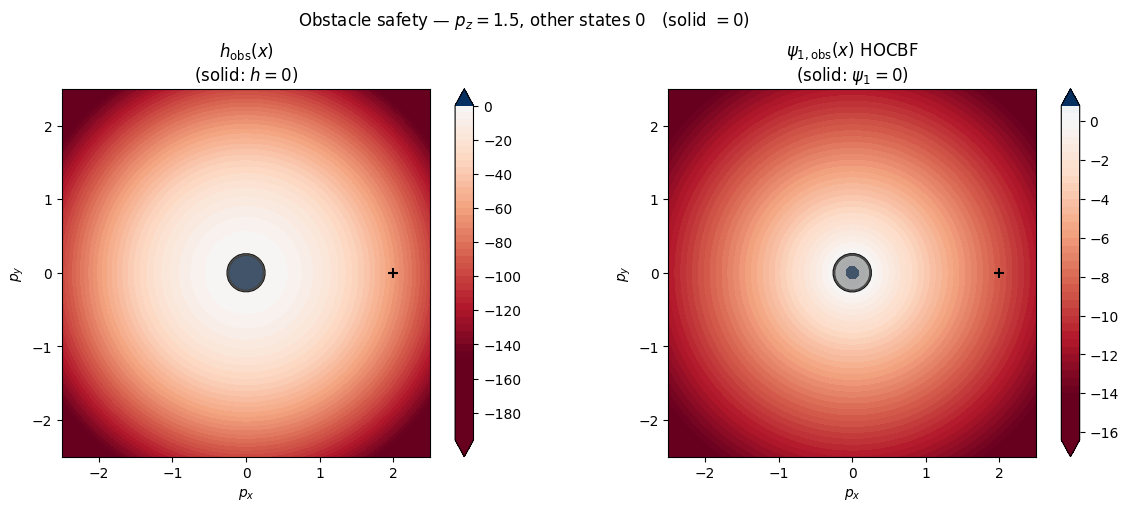

In [13]:
OBS_IDX = NH - 1   # obstacle is appended last in h_raw / B_hocbf

N_VIZ = 80
px_g, py_g = np.linspace(-2.5, 2.5, N_VIZ), np.linspace(-2.5, 2.5, N_VIZ)
PX_G, PY_G = np.meshgrid(px_g, py_g)

_x_base_viz = jnp.zeros(NX).at[task.PZ].set(Z_HOVER)
x_viz = (jnp.broadcast_to(_x_base_viz, (N_VIZ * N_VIZ, NX))
        .at[:, task.PX].set(PX_G.ravel())
        .at[:, task.PY].set(PY_G.ravel()))

h_viz = np.array(jax.vmap(h_raw)(x_viz)[:, OBS_IDX].reshape(N_VIZ, N_VIZ))
B_viz = np.array(jax.vmap(B_hocbf)(x_viz)[:, OBS_IDX].reshape(N_VIZ, N_VIZ))
print(f'h_obs ∈ [{h_viz.min():.2f}, {h_viz.max():.2f}]   '
      f'ψ1_obs ∈ [{B_viz.min():.2f}, {B_viz.max():.2f}]')

fig_viz, axes_viz = plt.subplots(1, 2, figsize=(12, 5), layout='constrained')
_titles = [
    r'$h_{\rm obs}(x)$' + chr(10) + r'(solid: $h=0$)',
    r'$\psi_{1,{\rm obs}}(x)$ HOCBF' + chr(10) + r'(solid: $\psi_1=0$)',
]
for ax, val_grid, title in zip(axes_viz, [h_viz, B_viz], _titles):
    # Percentile-based limits so the obstacle gradient isn't washed out by
    # very negative values far away.
    lim = float(np.percentile(np.abs(val_grid), 95)) * 1.01
    cf  = ax.contourf(px_g, py_g, val_grid, levels=50,
                      cmap='RdBu', vmin=-lim, vmax=lim, extend='both')
    ax.contour(px_g, py_g, val_grid, levels=[0.0], colors='k', linewidths=2.0)
    cx, cy, cz, r_obs = OBSTACLE
    ax.add_patch(Circle((cx, cy), r_obs,
                        facecolor='0.45', edgecolor='0.4', alpha=0.55, zorder=3))
    ax.scatter(*np.array(GOAL_MC)[[task.PX, task.PY]], s=60, marker='+', color='k', zorder=5)
    ax.set_xlabel(r'$p_x$'); ax.set_ylabel(r'$p_y$')
    ax.set_aspect('equal'); ax.set_title(title)
    plt.colorbar(cf, ax=ax)
fig_viz.suptitle(rf'Obstacle safety — $p_z={Z_HOVER}$, other states 0   '
                  r'(solid $= 0$)')
plt.show()


h_max(floor,ceil,obs) ∈ [-1.68, 0.98]   ψ1_max ∈ [-1.68, 1.09]


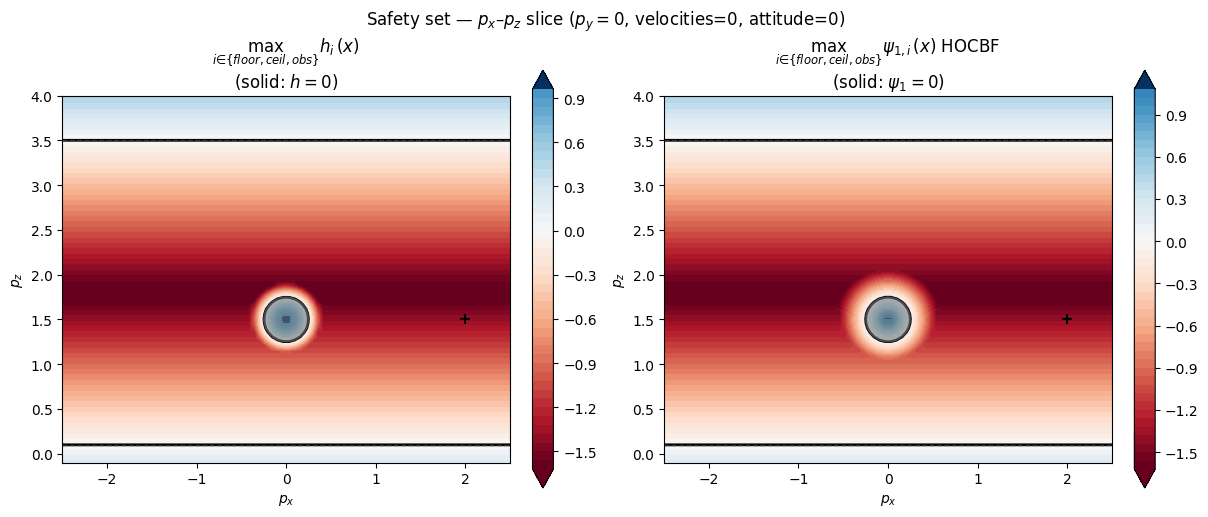

In [14]:
# ── (px, pz) slice: shows floor + ceiling + obstacle simultaneously ──────────
# Take max over constraint indices [floor, ceil, obs]; roll/pitch are constant
# at zero attitude so we exclude them.
_XZ_IDX = jnp.array([0, 1, NH - 1])   # floor, ceil, obstacle

N_VIZ_XZ = 80
px_g  = np.linspace(-2.5, 2.5, N_VIZ_XZ)
pz_g  = np.linspace(-0.1, 4.0, N_VIZ_XZ)
PX_G, PZ_G = np.meshgrid(px_g, pz_g)

_x_base_xz = jnp.zeros(NX)
x_xz = (jnp.broadcast_to(_x_base_xz, (N_VIZ_XZ * N_VIZ_XZ, NX))
        .at[:, task.PX].set(PX_G.ravel())
        .at[:, task.PZ].set(PZ_G.ravel()))

h_xz = np.array(jax.vmap(h_raw)(x_xz)[:, _XZ_IDX].max(axis=-1).reshape(N_VIZ_XZ, N_VIZ_XZ))
B_xz = np.array(jax.vmap(B_hocbf)(x_xz)[:, _XZ_IDX].max(axis=-1).reshape(N_VIZ_XZ, N_VIZ_XZ))
print(f'h_max(floor,ceil,obs) ∈ [{h_xz.min():.2f}, {h_xz.max():.2f}]   '
      f'ψ1_max ∈ [{B_xz.min():.2f}, {B_xz.max():.2f}]')

fig_xz, axes_xz = plt.subplots(1, 2, figsize=(12, 5), layout='constrained')
_titles_xz = [
    r'$\max_{i \in \{floor, ceil, obs\}} h_i(x)$' + chr(10) + r'(solid: $h=0$)',
    r'$\max_{i \in \{floor, ceil, obs\}} \psi_{1,i}(x)$ HOCBF' + chr(10) + r'(solid: $\psi_1=0$)',
]

cx, cy, cz, r_obs = OBSTACLE
for ax, val_grid, title in zip(axes_xz, [h_xz, B_xz], _titles_xz):
    lim = float(np.percentile(np.abs(val_grid), 95)) * 1.01
    cf  = ax.contourf(px_g, pz_g, val_grid, levels=50,
                      cmap='RdBu', vmin=-lim, vmax=lim, extend='both')
    ax.contour(px_g, pz_g, val_grid, levels=[0.0], colors='k', linewidths=2.0)
    # Floor / ceiling lines + obstacle slice (circle at py=0 ⇒ effective radius shrinks)
    ax.axhline(task.Z_MIN, color='0.2', ls='--', lw=1.0)
    ax.axhline(task.Z_MAX, color='0.2', ls='--', lw=1.0)
    ax.add_patch(Circle((cx, cz), r_obs,
                        facecolor='0.45', edgecolor='0.4', alpha=0.55, zorder=3))
    ax.scatter(float(GOAL_MC[task.PX]), float(GOAL_MC[task.PZ]),
               s=60, marker='+', color='k', zorder=5)
    ax.set_xlabel(r'$p_x$'); ax.set_ylabel(r'$p_z$')
    ax.set_aspect('equal'); ax.set_title(title)
    plt.colorbar(cf, ax=ax)

fig_xz.suptitle(r'Safety set — $p_x$–$p_z$ slice ($p_y=0$, velocities=0, attitude=0)')
plt.show()


## Demo rollout — single trajectory


In [15]:
print('Available devices:', jax.devices())
print('Default backend:', jax.default_backend())

rollout_nom          = _make_rollout(_nom_step)
rollout_cbf          = _make_rollout(_cbf_step)
rollout_rcbf         = _make_rollout(_rcbf_step)
rollout_duality      = _make_rollout(_duality_step)
rollout_rcbf_02      = _make_rollout(_make_rcbf_fixed_step(0.2))
rollout_rcbf_10      = _make_rollout(_make_rcbf_fixed_step(1.0))
rollout_mrcbf        = _make_rollout(_mrcbf_step)
rollout_nmr_pretrain = _make_rollout(_nmr_pretrain_step)
rollout_nmr_finetune = _make_rollout(_nmr_finetune_step)
rollout_lfhwc        = _make_rollout(_lfhwc_step)

_ALL_ROLLOUTS = [
    ('Nominal',        rollout_nom),
    ('CBF',            rollout_cbf),
    # ('R-CBF (0.2)',    rollout_rcbf_02),
    # ('R-CBF (1.0)',    rollout_rcbf_10),
    # ('R-CBF-QP',       rollout_rcbf),
    # ('Duality CBF',    rollout_duality),
    ('PSHR-CBF',       rollout_lfhwc),
    ('NMR-CBF',        rollout_nmr_pretrain),
    # ('NMR-CBF (RL)',   rollout_nmr_finetune),
]

# Demo IC: start to the left at hover, biased TOWARDS the obstacle.
X0_DEMO   = jnp.zeros(NX).at[task.PX].set(-1.8).at[task.PZ].set(Z_HOVER-0.1).at[task.PY].set(0.2)
BIAS_DEMO = jnp.zeros(NX).at[task.PX].set(-STATE_EPS[task.PX]).at[task.PZ].set(-STATE_EPS[task.PZ])  # bias px so true state appears closer to goal

print('Precompiling rollouts...')
for name, fn in _ALL_ROLLOUTS:
    jax.block_until_ready(fn(X0_DEMO, BIAS_DEMO))
    print(f'  {name:<16}  compiled')

print('\nDemo rollout (obstacle violated?):')
results = {}
for name, fn in _ALL_ROLLOUTS:
    xs, xhats = jax.device_get(fn(X0_DEMO, BIAS_DEMO))
    results[name] = dict(xs=xs, xhats=xhats)
    h_traj = np.array(jax.vmap(h_raw)(jnp.array(xs)))
    viol = bool(h_traj.max() > 0)
    print(f'  {name:<16}  {viol}   (max h_raw = {h_traj.max():+.3f})')


Available devices: [cuda(id=1)]
Default backend: gpu
Precompiling rollouts...


2026-07-05 13:50:13.184 | DEBUG    | jaxproxqp.settings:default:62 - Using default settings for float32


  Nominal           compiled
  CBF               compiled
  PSHR-CBF          compiled
  NMR-CBF           compiled

Demo rollout (obstacle violated?):
  Nominal           True   (max h_raw = +0.615)
  CBF               True   (max h_raw = +0.017)
  PSHR-CBF          False   (max h_raw = -0.817)
  NMR-CBF           False   (max h_raw = -0.780)


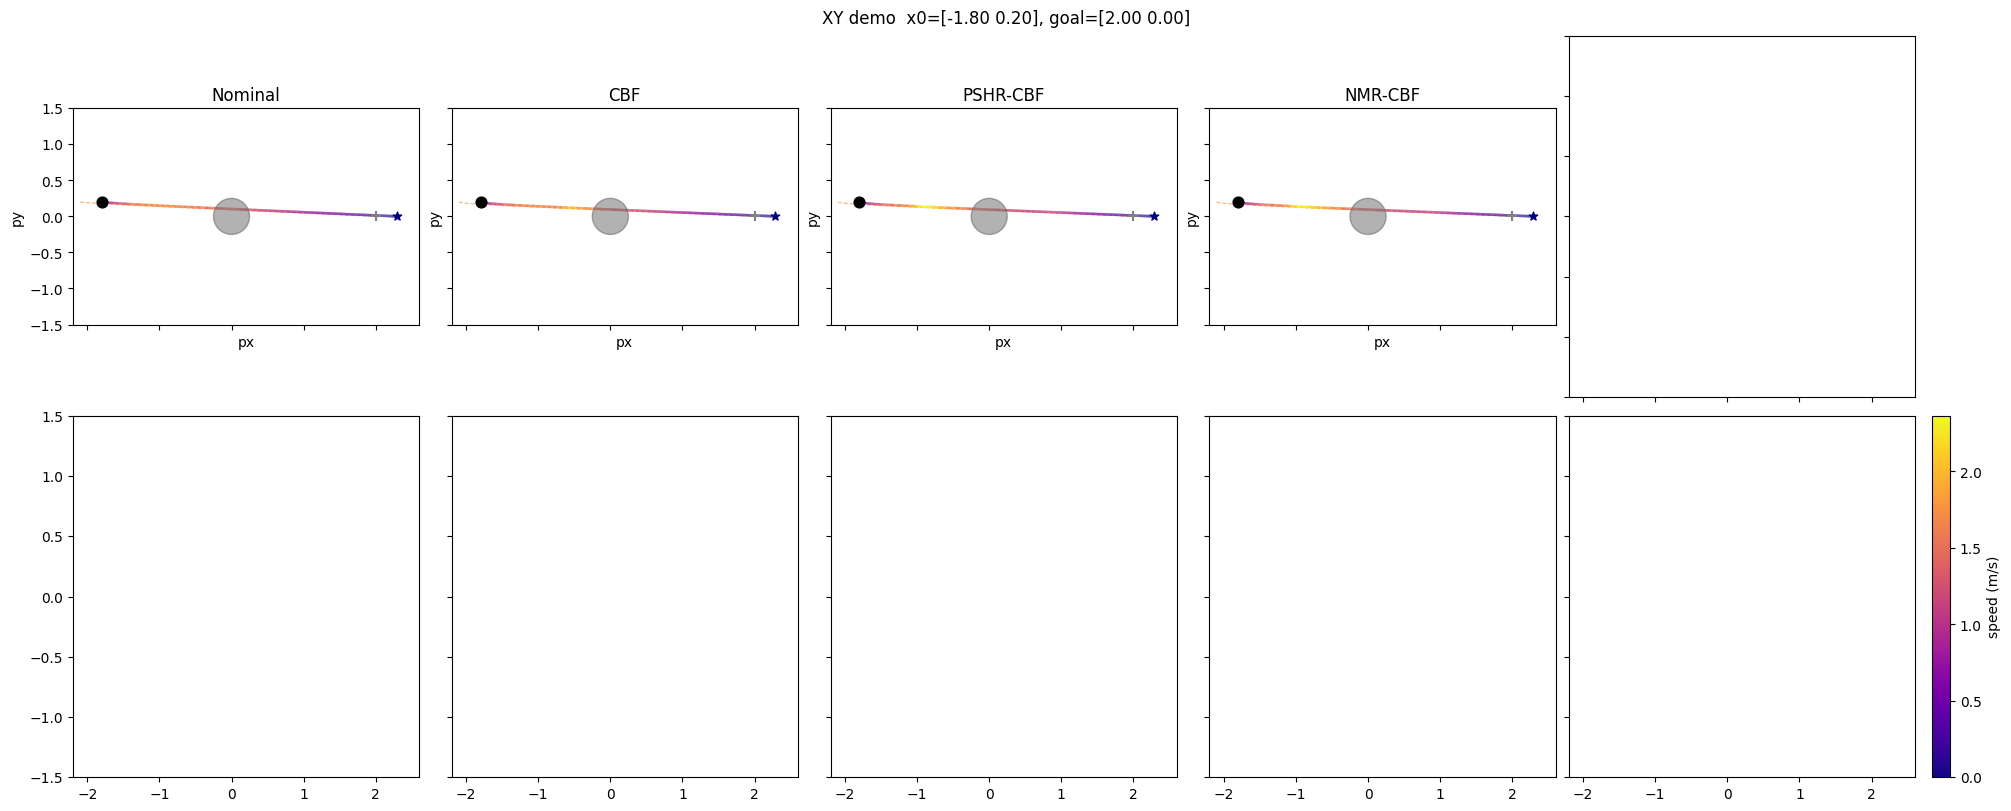

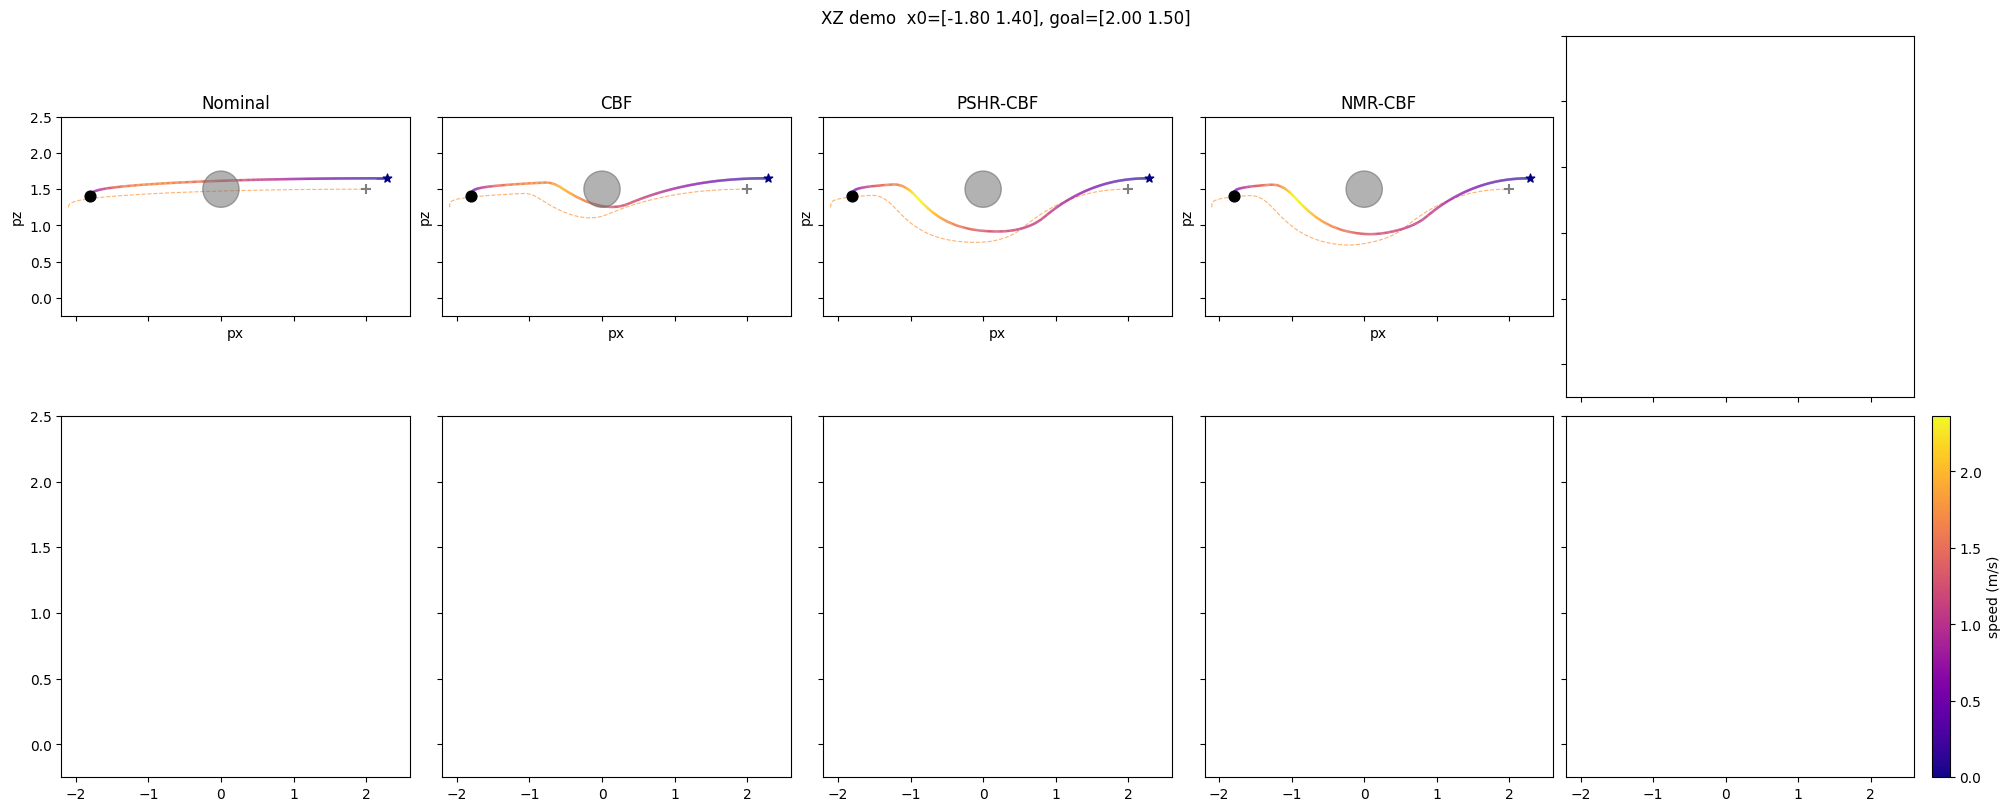

In [16]:
_XLIM = (-2.2, 2.6)
_YLIM = (-1.5, 1.5)

fig, axes = plt.subplots(2, 5, figsize=(20, 8), layout='constrained',
                          sharex=True, sharey=True)
axes = axes.flatten()

# Speed at each timestep
_all_speeds = []
_vmax_in_window = []
for d in results.values():
    xs    = d['xs']
    speed = np.sqrt(xs[:, task.VX]**2 + xs[:, task.VY]**2 + xs[:, task.VZ]**2)
    _all_speeds.append(speed)
    in_window = (np.abs(xs[:, task.PX]) <= _XLIM[1]) & (np.abs(xs[:, task.PY]) <= _YLIM[1])
    if in_window.any():
        _vmax_in_window.append(float(speed[in_window].max()))

_speed_norm = plt.Normalize(0, max(_vmax_in_window) if _vmax_in_window else 1.0)

cx, cy, cz, r_obs = OBSTACLE
lc_last = None
for ax, (name, d), speed in zip(axes, results.items(), _all_speeds):
    xs, xhats = d['xs'], d['xhats']
    pts  = np.stack([xs[:, task.PX], xs[:, task.PY]], axis=1).reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc   = LineCollection(segs, cmap='plasma', norm=_speed_norm, lw=1.8, zorder=3)
    lc.set_array((speed[:-1] + speed[1:]) / 2)
    ax.add_collection(lc)
    ax.plot(xhats[:, task.PX], xhats[:, task.PY],
            color='C1', lw=0.8, ls='--', alpha=0.6)
    ax.scatter(xs[0, task.PX], xs[0, task.PY], s=60, color='k', zorder=6)
    ax.scatter(xs[-1, task.PX], xs[-1, task.PY], s=40, color='navy', marker='*', zorder=6)
    ax.scatter(*np.array(GOAL_MC)[[task.PX, task.PY]], s=50, color='gray', marker='+', zorder=5)
    ax.add_patch(Circle((cx, cy), r_obs, facecolor='0.45', edgecolor='0.4', alpha=0.55, zorder=4))
    ax.set_xlim(*_XLIM); ax.set_ylim(*_YLIM); ax.set_aspect('equal')
    ax.set_xlabel('px'); ax.set_ylabel('py'); ax.set_title(name)
    lc_last = lc

if lc_last is not None:
    fig.colorbar(lc_last, ax=axes[-1], label='speed (m/s)')
fig.suptitle(
    f'XY demo  x0={np.array2string(np.array([float(X0_DEMO[task.PX]), float(X0_DEMO[task.PY])]), formatter={"float_kind":lambda v: f"{v:.2f}"})}, '
    f'goal={np.array2string(np.array([float(GOAL_MC[task.PX]), float(GOAL_MC[task.PY])]), formatter={"float_kind":lambda v: f"{v:.2f}"})}'
)
plt.show()

_ZLIM = (-0.25, 2.5)

fig, axes = plt.subplots(2, 5, figsize=(20, 8), layout='constrained',
                          sharex=True, sharey=True)
axes = axes.flatten()

# Speed at each timestep
_all_speeds = []
_vmax_in_window = []
for d in results.values():
    xs    = d['xs']
    speed = np.sqrt(xs[:, task.VX]**2 + xs[:, task.VY]**2 + xs[:, task.VZ]**2)
    _all_speeds.append(speed)
    in_window = (np.abs(xs[:, task.PX]) <= _XLIM[1]) & (np.abs(xs[:, task.PZ]) <= _ZLIM[1])
    if in_window.any():
        _vmax_in_window.append(float(speed[in_window].max()))

_speed_norm = plt.Normalize(0, max(_vmax_in_window) if _vmax_in_window else 1.0)

cx, cy, cz, r_obs = OBSTACLE
lc_last = None
for ax, (name, d), speed in zip(axes, results.items(), _all_speeds):
    xs, xhats = d['xs'], d['xhats']
    pts  = np.stack([xs[:, task.PX], xs[:, task.PZ]], axis=1).reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc   = LineCollection(segs, cmap='plasma', norm=_speed_norm, lw=1.8, zorder=3)
    lc.set_array((speed[:-1] + speed[1:]) / 2)
    ax.add_collection(lc)
    ax.plot(xhats[:, task.PX], xhats[:, task.PZ],
            color='C1', lw=0.8, ls='--', alpha=0.6)
    ax.scatter(xs[0, task.PX], xs[0, task.PZ], s=60, color='k', zorder=6)
    ax.scatter(xs[-1, task.PX], xs[-1, task.PZ], s=40, color='navy', marker='*', zorder=6)
    ax.scatter(*np.array(GOAL_MC)[[task.PX, task.PZ]], s=50, color='gray', marker='+', zorder=5)
    ax.add_patch(Circle((cx, cz), r_obs, facecolor='0.45', edgecolor='0.4', alpha=0.55, zorder=4))
    ax.set_xlim(*_XLIM); ax.set_ylim(*_ZLIM); ax.set_aspect('equal')
    ax.set_xlabel('px'); ax.set_ylabel('pz'); ax.set_title(name)
    lc_last = lc

if lc_last is not None:
    fig.colorbar(lc_last, ax=axes[-1], label='speed (m/s)')
fig.suptitle(
    f'XZ demo  x0={np.array2string(np.array([float(X0_DEMO[task.PX]), float(X0_DEMO[task.PZ])]), formatter={"float_kind":lambda v: f"{v:.2f}"})}, '
    f'goal={np.array2string(np.array([float(GOAL_MC[task.PX]), float(GOAL_MC[task.PZ])]), formatter={"float_kind":lambda v: f"{v:.2f}"})}'
)
plt.show()


## Monte Carlo safety evaluation


In [6]:
GOAL_TOL  = 0.3    # m  — final position tolerance (looser than dbint due to 3-D goal)
VEL_TOL   = 0.2    # m/s
N_MC      = 1_000
# Sampling box for (px0, py0) at hover altitude, all other states zero.
MC_BOUNDS = np.array([[-1.5, -0.25, Z_HOVER-0.25], [-2.0, 0.25, Z_HOVER+0.25]])

_eps_px_val    = float(STATE_EPS[task.PX])
_mc_cache_file = _mc_results_dir / f'mc_eps_{_eps_px_val:.3f}.pkl'

rng_mc = jr.PRNGKey(42)
rng_mc, rng_ic, rng_bias = jr.split(rng_mc, 3)
x0pos  = jr.uniform(rng_ic, (N_MC, 3), minval=MC_BOUNDS[0], maxval=MC_BOUNDS[1])

_x_base = jnp.zeros(NX).at[task.PZ].set(Z_HOVER)
x0s = jnp.broadcast_to(_x_base, (N_MC, NX))
x0s = x0s.at[:, task.PX].set(x0pos[:, 0]).at[:, task.PY].set(x0pos[:, 1]).at[:, task.PZ].set(x0pos[:, 2])

biases = jr.uniform(rng_bias, (N_MC, NX), minval=-STATE_EPS, maxval=STATE_EPS)
print(f'x0s {x0s.shape}  biases {biases.shape}')

mc_results     = {}
mc_goals       = {}
mc_viols       = {}
mc_reached     = {}
mc_reach_times = {}

_loaded_from_cache = False
if _mc_cache_file.exists():
    with open(_mc_cache_file, 'rb') as _f:
        _cached = pickle.load(_f)
    if 'violation_array' in _cached and 'reached_array' in _cached:
        print(f'Loading cached MC results from {_mc_cache_file}')
        N_MC = _cached['N_MC']
        mc_viols       = {k: np.array(v, dtype=bool) for k, v in _cached['violation_array'].items()}
        mc_reached     = {k: np.array(v, dtype=bool) for k, v in _cached['reached_array'].items()}
        mc_reach_times = {k: np.array(v)             for k, v in _cached.get('reach_time_array', {}).items()}
        mc_results = _cached['violation_rates']
        mc_goals   = _cached['goal_rates']
        _loaded_from_cache = True
        for name in mc_viols:
            print(f'  {name:<16}  viol={mc_results[name]:.0%}  goal={mc_goals[name]:.0%}')
    else:
        print('Cache file exists but missing arrays — will re-run.')

if not _loaded_from_cache:
    _mc_fns = [
        ('Nominal',        jax.jit(jax.vmap(rollout_nom))),
        ('CBF',            jax.jit(jax.vmap(rollout_cbf))),
        ('R-CBF-QP',       jax.jit(jax.vmap(rollout_rcbf))),
        ('R-CBF (0.2)',    jax.jit(jax.vmap(rollout_rcbf_02))),
        ('R-CBF (1.0)',    jax.jit(jax.vmap(rollout_rcbf_10))),
        # ('MR-CBF',         jax.jit(jax.vmap(rollout_mrcbf))),
        ('PSHR-CBF',       jax.jit(jax.vmap(rollout_lfhwc))),
        ('NMR-CBF',        jax.jit(jax.vmap(rollout_nmr_pretrain))),
        ('NMR-CBF (RL)',   jax.jit(jax.vmap(rollout_nmr_finetune))),
        # ('Duality CBF',    jax.jit(jax.vmap(rollout_duality))),
    ]

    _h_mc = jax.jit(jax.vmap(jax.vmap(h_raw)))   # (N, T+1, nx) → (N, T+1, nh)

    print(f'Running MC (N={N_MC}, T={T*DT:.0f}s, pos_tol={GOAL_TOL}m, vel_tol={VEL_TOL}m/s)...')
    for name, mc_fn in _mc_fns:
        xs_all, xhats_all = jax.device_get(mc_fn(x0s, biases))   # (N, T+1, NX), (N, T, NX)
        # Safety check on true state
        h_all = np.array(_h_mc(jnp.array(xs_all)))                # (N, T+1, nh)
        viols = h_all.max(axis=(1, 2)) > 0
        # Reached: true px past obstacle and total speed under tolerance
        px_f    = xs_all[:, -1, task.PX]
        speed_f = np.sqrt(xs_all[:, -1, task.VX]**2 + xs_all[:, -1, task.VY]**2 + xs_all[:, -1, task.VZ]**2)
        reached = (px_f >= float(OBSTACLE[0]) + 0.5) & (speed_f <= VEL_TOL)
        mc_viols[name]   = viols
        mc_reached[name] = reached
        mc_results[name] = float(viols.mean())
        mc_goals[name]   = float(reached.mean())
        # Reach time
        px_t   = xs_all[:, :, task.PX]
        spd_t  = np.sqrt(xs_all[:, :, task.VX]**2 + xs_all[:, :, task.VY]**2 + xs_all[:, :, task.VZ]**2)
        in_goal = (px_t >= float(OBSTACLE[0]) + 0.5) & (spd_t <= VEL_TOL)
        ever    = in_goal.any(axis=1)
        first_t = np.argmax(in_goal, axis=1)
        mc_reach_times[name] = np.where(ever, first_t * DT, np.nan)
        print(f'  {name:<16}  viol={mc_results[name]:.0%} ({int(viols.sum())}/{N_MC})'
              f'  goal={mc_goals[name]:.0%} ({int(reached.sum())}/{N_MC})'
              f'  t_reach_mean={float(np.nanmean(mc_reach_times[name])):.3f}s')


x0s (1000, 12)  biases (1000, 12)
Loading cached MC results from /home/nrober/code/pncbf/pncbf/runs/nmr_cbf_quad3d/policies/obs0.00_0.00_1.50_r0.25/mc_results/mc_eps_0.300.pkl
  Nominal           viol=82%  goal=100%
  CBF               viol=18%  goal=100%
  R-CBF-QP          viol=16%  goal=100%
  R-CBF (0.2)       viol=16%  goal=100%
  R-CBF (1.0)       viol=4%  goal=100%
  PSHR-CBF          viol=0%  goal=100%
  NMR-CBF           viol=0%  goal=100%
  NMR-CBF (RL)      viol=0%  goal=100%
  Duality CBF       viol=0%  goal=98%


In [19]:
if not _loaded_from_cache:
    _mc_results_dir.mkdir(parents=True, exist_ok=True)
    _mc_save = {
        'STATE_EPS':       np.array(STATE_EPS),
        'N_MC':            N_MC,
        'px0':             np.array(x0s[:, task.PX]),
        'py0':             np.array(x0s[:, task.PY]),
        'pz0':             np.array(x0s[:, task.PZ]),
        'violation_rates': mc_results,
        'goal_rates':      mc_goals,
        'violation_array':  {k: v.tolist() for k, v in mc_viols.items()},
        'reached_array':    {k: v.tolist() for k, v in mc_reached.items()},
        'reach_time_array': {k: v.tolist() for k, v in mc_reach_times.items()},
    }
    with open(_mc_cache_file, 'wb') as _f:
        pickle.dump(_mc_save, _f)
    print(f'Saved MC results to {_mc_cache_file}')
else:
    print(f'Results loaded from cache ({_mc_cache_file.name}) — nothing to save.')


Results loaded from cache (mc_eps_0.300.pkl) — nothing to save.


In [ ]:
# ── Backfill PSHR-CBF results into existing MC cache files ────────────────────
# Safe to re-run: files that already contain 'PSHR-CBF' are skipped unless FORCE.
import pickle
from pathlib import Path

FORCE_BACKFILL = False

_bf_files = sorted(_mc_results_dir.glob('mc_eps_*.pkl')) if _mc_results_dir.exists() else []
if not _bf_files:
    print(f'No MC cache files found in {_mc_results_dir}')
else:
    _h_bf = jax.jit(jax.vmap(jax.vmap(h_raw)))

    def _make_pshr_step_bf(state_eps):
        """PSHR-CBF step that closes over state_eps — forces recompile per eps."""
        def _step(carry, step_idx, goal):
            x, bias   = carry
            xhat      = x + bias
            lo        = xhat - state_eps
            hi        = xhat + state_eps
            u_nom     = nom_pol_goto(xhat, goal)
            opt_key   = jr.fold_in(BASE_KEY, step_idx)

            h_nom  = B_hocbf(xhat)
            J_nom  = jax.jacobian(B_hocbf)(xhat)
            Lf_nom = J_nom @ f(xhat)
            keys = jr.split(opt_key, NH)

            def worst_i(i, k):
                _, x_wc = proj_grad_max_box(
                    lambda xi: (jax.jacobian(B_hocbf)(xi) @ f(xi) + ALPHA_QP_VEC * B_hocbf(xi))[i],
                    lo, hi, n_restarts=4, n_steps=25, lr=0.03, key=k)
                h_wc_i  = B_hocbf(x_wc)[i]
                Lf_wc_i = (jax.jacobian(B_hocbf)(x_wc) @ f(x_wc))[i]
                return h_wc_i, Lf_wc_i

            h_wc, Lf_wc = jax.vmap(worst_i)(jnp.arange(NH), keys)
            phi_oracle = (Lf_wc + ALPHA_QP_VEC * h_wc) - (Lf_nom + ALPHA_QP_VEC * h_nom)
            u, _, _ = min_norm_cbf(ALPHA_QP_VEC, u_lb, u_ub, h_nom + phi_oracle / ALPHA_QP_VEC, J_nom,
                                    f(xhat), G(xhat), u_nom, relax_eps2=0.1)
            return (x + DT * (f(x) + G(x) @ u), bias), (x, xhat)
        return _step

    for fp in _bf_files:
        with open(fp, 'rb') as fh:
            data = pickle.load(fh)

        if not FORCE_BACKFILL and 'PSHR-CBF' in data.get('violation_array', {}):
            print(f'  skipping {fp.name} — PSHR-CBF already present')
            continue

        bf_N_MC      = data['N_MC']
        bf_STATE_EPS = jnp.array(data['STATE_EPS'])
        bf_px0       = np.array(data['px0'])
        bf_py0       = np.array(data['py0'])
        print(f'{fp.name}: compiling PSHR-CBF for STATE_EPS={np.array(bf_STATE_EPS)}...')

        bf_rollout = _make_rollout(_make_pshr_step_bf(bf_STATE_EPS))
        bf_vmap    = jax.jit(jax.vmap(bf_rollout))
        jax.block_until_ready(bf_vmap(jnp.zeros((1, NX)), jnp.zeros((1, NX))))
        print(f'  compiled, running {bf_N_MC} rollouts...')

        _xbase_bf = jnp.zeros(NX).at[task.PZ].set(Z_HOVER)
        bf_x0s = jnp.broadcast_to(_xbase_bf, (bf_N_MC, NX))
        bf_x0s = bf_x0s.at[:, task.PX].set(jnp.array(bf_px0)).at[:, task.PY].set(jnp.array(bf_py0))
        _, _, _rng_bias_bf = jr.split(jr.PRNGKey(42), 3)
        bf_biases = jr.uniform(_rng_bias_bf, (bf_N_MC, NX),
                               minval=-bf_STATE_EPS, maxval=bf_STATE_EPS)

        xs_all, xhats_all = jax.device_get(bf_vmap(bf_x0s, bf_biases))
        h_all  = np.array(_h_bf(jnp.array(xs_all)))
        viols  = h_all.max(axis=(1, 2)) > 0
        px_f    = xs_all[:, -1, task.PX]
        speed_f = np.sqrt(xs_all[:, -1, task.VX]**2 + xs_all[:, -1, task.VY]**2 + xs_all[:, -1, task.VZ]**2)
        reached = (px_f >= float(OBSTACLE[0]) + 0.5) & (speed_f <= VEL_TOL)
        px_t   = xs_all[:, :, task.PX]
        spd_t  = np.sqrt(xs_all[:, :, task.VX]**2 + xs_all[:, :, task.VY]**2 + xs_all[:, :, task.VZ]**2)
        in_goal = (px_t >= float(OBSTACLE[0]) + 0.5) & (spd_t <= VEL_TOL)
        ever     = in_goal.any(axis=1)
        first_t  = np.argmax(in_goal, axis=1)
        reach_times = np.where(ever, first_t * DT, np.nan)

        data['violation_array']['PSHR-CBF']  = viols.tolist()
        data['reached_array']['PSHR-CBF']    = reached.tolist()
        data.setdefault('reach_time_array', {})['PSHR-CBF'] = reach_times.tolist()
        data['violation_rates']['PSHR-CBF']  = float(viols.mean())
        data['goal_rates']['PSHR-CBF']       = float(reached.mean())

        with open(fp, 'wb') as fh:
            pickle.dump(data, fh)
        print(('  {:<16}  viol={:.0%} ({}/{})  goal={:.0%} ({}/{})'
               '  t_reach_mean={:.1f}s  -> saved {}').format(
            'PSHR-CBF', float(viols.mean()), int(viols.sum()), bf_N_MC,
            float(reached.mean()), int(reached.sum()), bf_N_MC,
            float(np.nanmean(reach_times)), fp.name))

    print('Backfill complete.')


In [38]:
# ── MC XY trajectory spaghetti — data collection ──────────────────────────────
N_PLOT = 200
_rng_sub    = np.random.default_rng(42)
_sub_idx    = _rng_sub.choice(N_MC, size=min(N_PLOT, N_MC), replace=False)
_x0s_sub    = x0s[_sub_idx]
_biases_sub = biases[_sub_idx]

_PLOT_ORDER = [
    'CBF', 'R-CBF (0.2)', 'R-CBF (1.0)', 'Duality CBF', 'R-CBF-QP',
    'MR-CBF', 'PSHR-CBF', 'NMR-CBF', 'NMR-CBF (RL)',
]
_name_to_rollout = dict(_ALL_ROLLOUTS)

print(f'Running {len(_sub_idx)} rollouts per policy...')
_sub_trajs = {}
for _name in _PLOT_ORDER:
    if _name not in _name_to_rollout:
        continue
    _fn = _name_to_rollout[_name]
    _xs_all, _ = jax.device_get(jax.jit(jax.vmap(_fn))(_x0s_sub, _biases_sub))
    _sub_trajs[_name] = np.array(_xs_all)
    print(f'  {_name} done')


Running 200 rollouts per policy...
  CBF done
  PSHR-CBF done
  NMR-CBF done


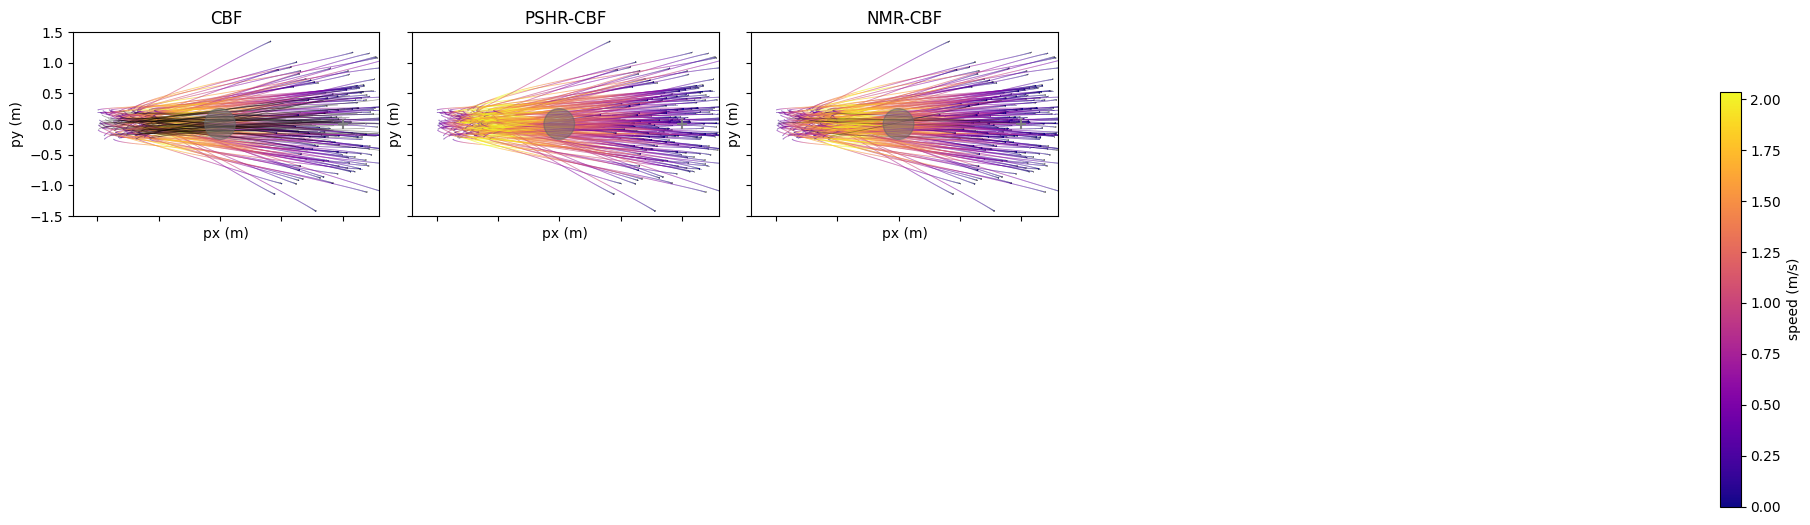

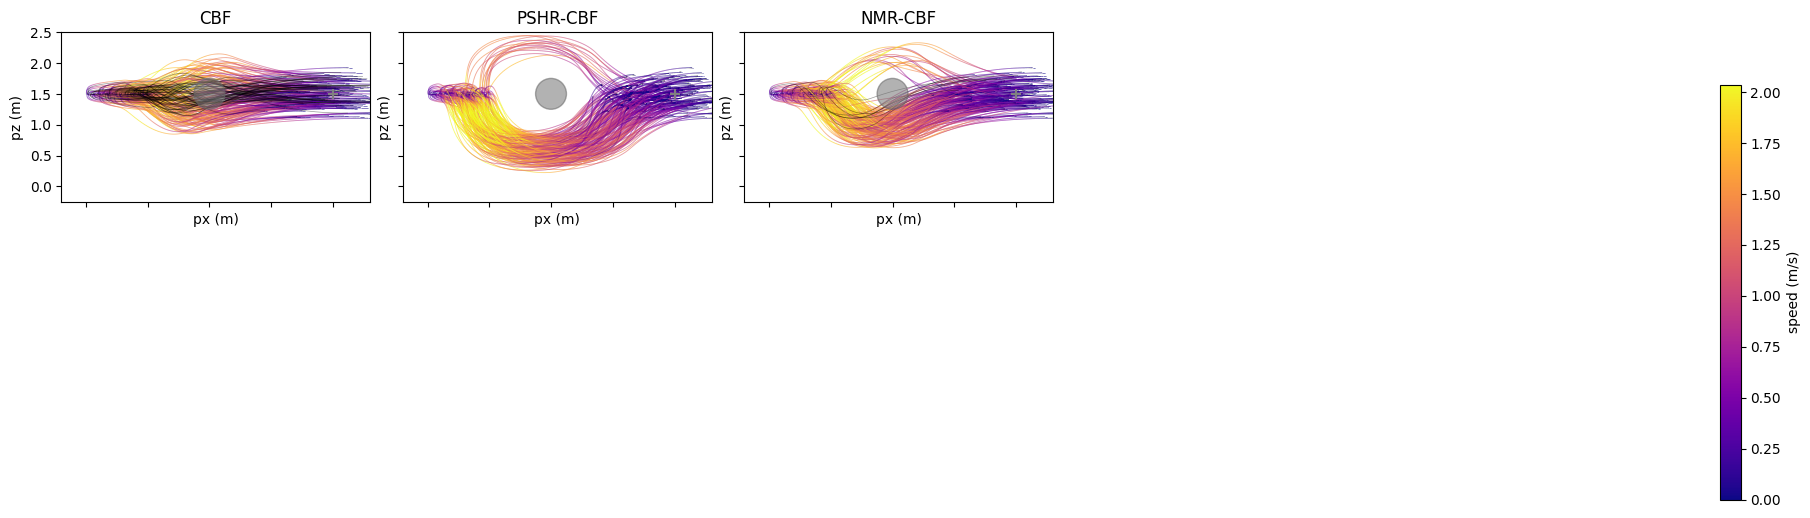

In [ ]:
_XLIM = (-2.4, 2.6)
_YLIM = (-1.5, 1.5)

_sub_viols = {}
_h_sub = jax.jit(jax.vmap(jax.vmap(h_raw)))
for _name, _xs in _sub_trajs.items():
    _h_all = np.array(_h_sub(jnp.array(_xs)))
    _sub_viols[_name] = _h_all.max(axis=(1, 2)) > 0

_all_safe_speeds = np.concatenate([
    np.sqrt(_sub_trajs[n][~_sub_viols[n], :, task.VX]**2 +
            _sub_trajs[n][~_sub_viols[n], :, task.VY]**2 +
            _sub_trajs[n][~_sub_viols[n], :, task.VZ]**2).ravel()
    for n in _sub_trajs if (~_sub_viols[n]).any()
])
_speed_vmax = float(np.percentile(_all_safe_speeds, 99)) if len(_all_safe_speeds) else 1.0
_speed_norm = plt.Normalize(0, _speed_vmax)
_cmap = plt.cm.plasma

fig, axes = plt.subplots(2, 5, figsize=(18, 7), layout='constrained', sharex=True, sharey=True)
axes = axes.flatten()

cx, cy, cz, r_obs = OBSTACLE
for ax, _name in zip(axes, list(_sub_trajs.keys())):
    _xs   = _sub_trajs[_name]
    _viol = _sub_viols[_name]
    _speed   = np.sqrt(_xs[:, :, task.VX]**2 + _xs[:, :, task.VY]**2 + _xs[:, :, task.VZ]**2)
    _seg_spd = 0.5 * (_speed[:, :-1] + _speed[:, 1:])

    _safe = ~_viol
    if _safe.any():
        _sx   = _xs[_safe]
        _pts  = np.stack([_sx[:, :, task.PX], _sx[:, :, task.PY]], axis=2)
        _segs = np.concatenate([_pts[:, :-1, None, :], _pts[:, 1:, None, :]], axis=2)
        _segs = _segs.reshape(-1, 2, 2)
        _cols = _seg_spd[_safe].ravel()
        _rgba = _cmap(_speed_norm(_cols)); _rgba[:, 3] = 0.7
        lc = LineCollection(_segs, colors=_rgba, lw=0.6, zorder=3)
        ax.add_collection(lc)

    if _viol.any():
        ax.plot(_xs[_viol, :, task.PX].T, _xs[_viol, :, task.PY].T,
                color='k', lw=0.5, alpha=0.4, zorder=4)

    ax.add_patch(Circle((cx, cy), r_obs, facecolor='0.45', edgecolor='0.4', alpha=0.55, zorder=5))
    ax.scatter(*np.array(GOAL_MC)[[task.PX, task.PY]], s=50, color='gray', marker='+', zorder=6)
    ax.set_xlim(*_XLIM); ax.set_ylim(*_YLIM); ax.set_aspect('equal')
    ax.set_xlabel('px (m)'); ax.set_ylabel('py (m)'); ax.set_title(_name)

for ax in axes[len(_sub_trajs):]:
    ax.set_visible(False)

_sm = plt.cm.ScalarMappable(cmap=_cmap, norm=_speed_norm); _sm.set_array([])
fig.colorbar(_sm, ax=axes.tolist(), label='speed (m/s)', shrink=0.6, pad=0.02)
plt.show()

_ZLIM = (-0.25, 2.5)

_sub_viols = {}
_h_sub = jax.jit(jax.vmap(jax.vmap(h_raw)))
for _name, _xs in _sub_trajs.items():
    _h_all = np.array(_h_sub(jnp.array(_xs)))
    _sub_viols[_name] = _h_all.max(axis=(1, 2)) > 0

_all_safe_speeds = np.concatenate([
    np.sqrt(_sub_trajs[n][~_sub_viols[n], :, task.VX]**2 +
            _sub_trajs[n][~_sub_viols[n], :, task.VY]**2 +
            _sub_trajs[n][~_sub_viols[n], :, task.VZ]**2).ravel()
    for n in _sub_trajs if (~_sub_viols[n]).any()
])
_speed_vmax = float(np.percentile(_all_safe_speeds, 99)) if len(_all_safe_speeds) else 1.0
_speed_norm = plt.Normalize(0, _speed_vmax)
_cmap = plt.cm.plasma

fig, axes = plt.subplots(2, 5, figsize=(18, 7), layout='constrained', sharex=True, sharey=True)
axes = axes.flatten()

cx, cy, cz, r_obs = OBSTACLE
for ax, _name in zip(axes, list(_sub_trajs.keys())):
    _xs   = _sub_trajs[_name]
    _viol = _sub_viols[_name]
    _speed   = np.sqrt(_xs[:, :, task.VX]**2 + _xs[:, :, task.VY]**2 + _xs[:, :, task.VZ]**2)
    _seg_spd = 0.5 * (_speed[:, :-1] + _speed[:, 1:])

    _safe = ~_viol
    if _safe.any():
        _sx   = _xs[_safe]
        _pts  = np.stack([_sx[:, :, task.PX], _sx[:, :, task.PZ]], axis=2)
        _segs = np.concatenate([_pts[:, :-1, None, :], _pts[:, 1:, None, :]], axis=2)
        _segs = _segs.reshape(-1, 2, 2)
        _cols = _seg_spd[_safe].ravel()
        _rgba = _cmap(_speed_norm(_cols)); _rgba[:, 3] = 0.7
        lc = LineCollection(_segs, colors=_rgba, lw=0.6, zorder=3)
        ax.add_collection(lc)

    if _viol.any():
        ax.plot(_xs[_viol, :, task.PX].T, _xs[_viol, :, task.PZ].T,
                color='k', lw=0.5, alpha=0.4, zorder=4)

    ax.add_patch(Circle((cx, cz), r_obs, facecolor='0.45', edgecolor='0.4', alpha=0.55, zorder=5))
    ax.scatter(*np.array(GOAL_MC)[[task.PX, task.PZ]], s=50, color='gray', marker='+', zorder=6)
    ax.set_xlim(*_XLIM); ax.set_ylim(*_ZLIM); ax.set_aspect('equal')
    ax.set_xlabel('px (m)'); ax.set_ylabel('pz (m)'); ax.set_title(_name)

for ax in axes[len(_sub_trajs):]:
    ax.set_visible(False)

_sm = plt.cm.ScalarMappable(cmap=_cmap, norm=_speed_norm); _sm.set_array([])
fig.colorbar(_sm, ax=axes.tolist(), label='speed (m/s)', shrink=0.6, pad=0.02)
plt.show()



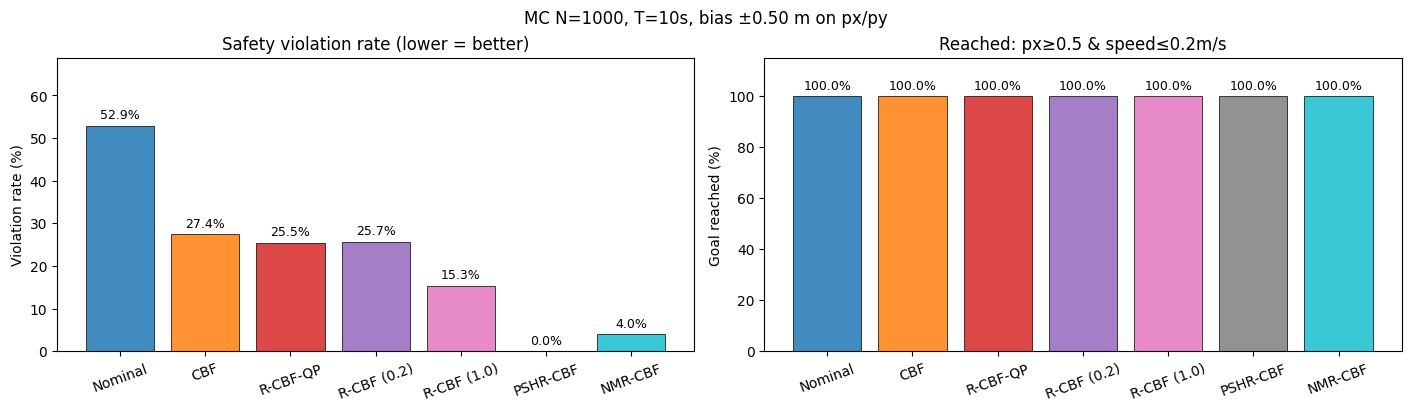

In [23]:
fig3, (ax_viol, ax_goal) = plt.subplots(1, 2, figsize=(14, 4), layout='constrained')
names  = list(mc_results.keys())
colors = plt.cm.tab10(np.linspace(0, 0.9, len(names)))

rates = [mc_results[n] * 100 for n in names]
bars  = ax_viol.bar(names, rates, color=colors, alpha=0.85, edgecolor='k', lw=0.6)
ax_viol.bar_label(bars, fmt='{:.1f}%', padding=3, fontsize=9)
ax_viol.set_ylabel('Violation rate (%)')
ax_viol.set_ylim(0, max(max(rates) * 1.3, 10))
ax_viol.set_title('Safety violation rate (lower = better)')
ax_viol.tick_params(axis='x', rotation=20)

goals = [mc_goals[n] * 100 for n in names]
bars2 = ax_goal.bar(names, goals, color=colors, alpha=0.85, edgecolor='k', lw=0.6)
ax_goal.bar_label(bars2, fmt='{:.1f}%', padding=3, fontsize=9)
ax_goal.set_ylabel('Goal reached (%)')
ax_goal.set_ylim(0, 115)
ax_goal.set_title(f'Reached: px≥{OBSTACLE[0]+0.5:.1f} & speed≤{VEL_TOL}m/s')
ax_goal.tick_params(axis='x', rotation=20)

fig3.suptitle(f'MC N={N_MC}, T={T*DT:.0f}s, bias ±{float(STATE_EPS[task.PX]):.2f} m on px/py')
plt.show()


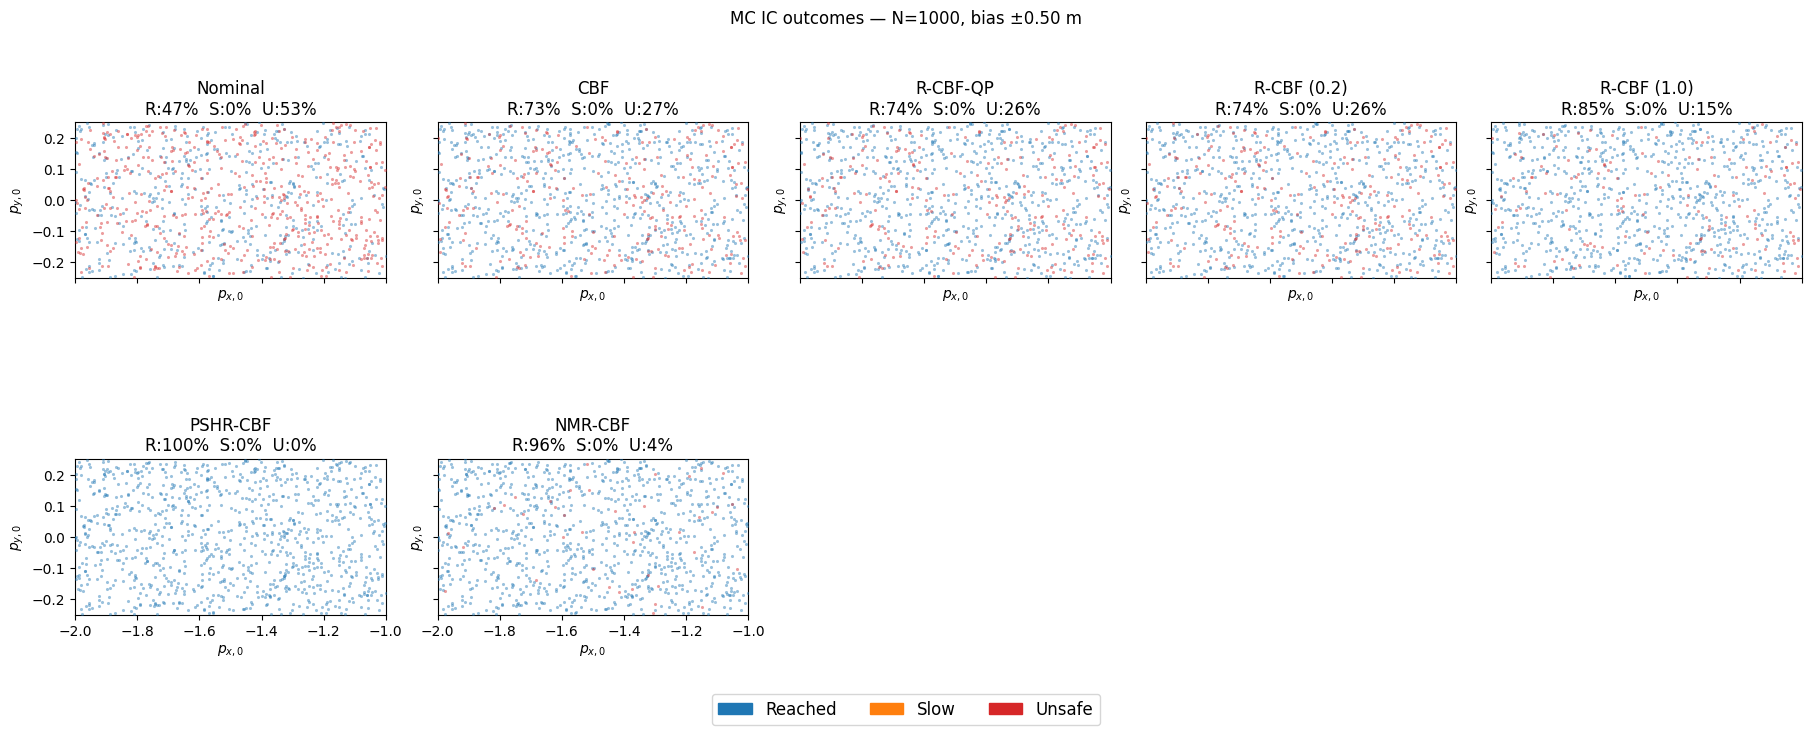

In [24]:
import matplotlib.patches as mpatches

_CAT_INFO = [
    ('Reached', 'C0', lambda v, r: (~v) &   r),
    ('Slow',    'C1', lambda v, r: (~v) & (~r)),
    ('Unsafe',  'C3', lambda v, r:   v),
]

_px0 = np.array(x0s[:, task.PX])
_py0 = np.array(x0s[:, task.PY])

fig_ic, axes_ic = plt.subplots(2, 5, figsize=(18, 7), layout='constrained',
                                sharex=True, sharey=True)
axes_ic = axes_ic.flatten()

cx, cy, cz, r_obs = OBSTACLE
for ax, (name, _fn) in zip(axes_ic, mc_viols.items()):
    viol    = mc_viols[name]
    reached = mc_reached[name]
    for cat, col, mask_fn in _CAT_INFO:
        mask = mask_fn(viol, reached)
        ax.scatter(_px0[mask], _py0[mask], c=col, s=5, alpha=0.45,
                   linewidths=0, zorder=3)
    ax.add_patch(Circle((cx, cy), r_obs,
                        facecolor='0.45', edgecolor='0.4', alpha=0.55, zorder=4))
    ax.set_aspect('equal')
    ax.set_xlim(*MC_BOUNDS[:, 0])
    ax.set_ylim(*MC_BOUNDS[:, 1])
    ax.set_xlabel(r'$p_{x,0}$'); ax.set_ylabel(r'$p_{y,0}$')
    n_r = int(((~viol) &   reached).sum())
    n_s = int(((~viol) & (~reached)).sum())
    n_u = int(viol.sum())
    ax.set_title(f'{name}\nR:{n_r/N_MC:.0%}  S:{n_s/N_MC:.0%}  U:{n_u/N_MC:.0%}')

for ax in axes_ic[len(mc_viols):]:
    ax.set_visible(False)

_handles = [mpatches.Patch(color=col, label=cat) for cat, col, _ in _CAT_INFO]
fig_ic.legend(handles=_handles, loc='lower center', ncol=3, fontsize=12,
              bbox_to_anchor=(0.5, -0.04))
fig_ic.suptitle(
    f'MC IC outcomes — N={N_MC}, bias ±{float(STATE_EPS[task.PX]):.2f} m')
plt.show()


## Outcome-rate table across epsilon values

Loads all cached MC results from `_mc_results_dir` (one file per `STATE_EPS` value).
To populate more columns: change `STATE_EPS`, re-run the MC + save cells.


In [ ]:
import pickle
import numpy as np

result_files = sorted(_mc_results_dir.glob('mc_eps_*.pkl')) if _mc_results_dir.exists() else []
if not result_files:
    print('No saved MC results found. Run the MC + save cells for each STATE_EPS value first.')
else:
    _all_cached = []
    for fp in result_files:
        with open(fp, 'rb') as fh:
            _all_cached.append(pickle.load(fh))
    _all_cached.sort(key=lambda r: float(r['STATE_EPS'][0]))

    TABLE_EPS_SUBSET = [0.10, 0.30]
    if TABLE_EPS_SUBSET is not None:
        _all_cached = [r for r in _all_cached
                        if any(abs(float(r['STATE_EPS'][0]) - e) < 1e-4 for e in TABLE_EPS_SUBSET)]

    if not _all_cached:
        print(f'No results match TABLE_EPS_SUBSET={TABLE_EPS_SUBSET}')
    else:
        available = list(_all_cached[0]['violation_rates'].keys())
        # Ordered category list. Each entry is (category label, [approach names]).
        CATEGORIES_ALL = [
            ('Non-robust',  ['Nominal', 'CBF']),
            ('Set-based',   ['Duality CBF']),
            ('Point-based', ['R-CBF (0.2)', 'R-CBF (1.0)', 'R-CBF-QP',
                             'PSHR-CBF', 'NMR-CBF', 'NMR-CBF (RL)']),
        ]
        # Drop approaches that weren't run for these epsilons, then drop empty categories.
        CATEGORIES = [(cat, [a for a in aps if a in available]) for cat, aps in CATEGORIES_ALL]
        CATEGORIES = [(cat, aps) for cat, aps in CATEGORIES if aps]

        table_eps_vals = [float(r['STATE_EPS'][0]) for r in _all_cached]
        n_eps    = len(table_eps_vals)
        col_spec = 'll' + 'ccc' * n_eps
        lines = [
            r'\begin{table}[t]', r'\centering', r'\scriptsize',
            r'\setlength{\tabcolsep}{4pt}',
            r'\caption{Time-to-goal (s) and Slow$\,/\,$Unsafe outcome rates (\%) vs.\ position noise $\varepsilon_p$ (m) on the 3D quadrotor.}',
            r'\label{nmrcbfs:tab:mc_outcome_rates_quad3d}',
            f'\\begin{{tabular}}{{@{{}}{col_spec}@{{}}}}', r'\toprule',
        ]
        header1 = r'Category & Approach'
        for eps in table_eps_vals:
            header1 += f' & \\multicolumn{{3}}{{c}}{{$\\varepsilon_p={eps:.2f}$}}'
        lines.append(header1 + r' \\')
        cmidrule_parts = []
        for k in range(n_eps):
            c0 = 3 + k * 3
            cmidrule_parts.append(f'\\cmidrule(lr){{{c0}-{c0+2}}}')
        lines.append(' '.join(cmidrule_parts))
        header2 = r' & '
        for _ in table_eps_vals:
            header2 += r' & Time & Slow & Unsafe'
        lines.append(header2 + r' \\')
        lines.append(r'\midrule')

        for ci, (cat, aps) in enumerate(CATEGORIES):
            n_ap = len(aps)
            for ai, approach in enumerate(aps):
                if ai == 0:
                    cat_cell = f'\\multirow{{{n_ap}}}{{*}}{{{cat}}}'
                else:
                    cat_cell = ''
                row = cat_cell + ' & ' + approach.replace('_', r'\_')
                for res in _all_cached:
                    # Mutually exclusive outcomes: Unsafe > Reached-safely > Slow.
                    viols_arr   = np.array(res['violation_array'].get(approach, []), dtype=bool)
                    reached_arr = np.array(res['reached_array'  ].get(approach, []), dtype=bool)
                    if viols_arr.size == 0:
                        unsafe = slow = float('nan')
                    else:
                        safe          = ~viols_arr
                        reached_safe  = safe & reached_arr
                        slow_mask     = safe & ~reached_arr
                        unsafe = float(viols_arr.mean())
                        slow   = float(slow_mask.mean())
                    # Time-to-goal averaged over trajectories that reached the goal safely.
                    rt_arr = res.get('reach_time_array', {}).get(approach, None)
                    if rt_arr is None or viols_arr.size == 0:
                        t_mean = float('nan')
                    else:
                        rt = np.array(rt_arr, dtype=float)
                        rt_safe = np.where(reached_safe, rt, np.nan)
                        with np.errstate(all='ignore'):
                            t_mean = float(np.nanmean(rt_safe)) if np.any(reached_safe) else float('nan')
                    t_str = '---' if not np.isfinite(t_mean) else f'{t_mean:.2f}'
                    row += f' & {t_str} & {100*slow:.1f} & {100*unsafe:.1f}'
                lines.append(row + r' \\')
            if ci < len(CATEGORIES) - 1:
                lines.append(r'\midrule')

        lines += [r'\bottomrule', r'\end{tabular}', r'\end{table}']
        print('\n'.join(lines))
        n_ap_total = sum(len(aps) for _, aps in CATEGORIES)
        print(f'\n({n_eps} ε values, {n_ap_total} approaches, N={_all_cached[0]["N_MC"]})')


\begin{table}[t]
\centering
\scriptsize
\setlength{\tabcolsep}{4pt}
\caption{Time-to-goal (s) and Slow$\,/\,$Unsafe outcome rates (\%) vs.\ position noise $\varepsilon_p$ (m) on the 3D quadrotor.}
\label{nmrcbfs:tab:mc_outcome_rates_quad3d}
\begin{tabular}{@{}llcccccc@{}}
\toprule
Category & Approach & \multicolumn{3}{c}{$\varepsilon_p=0.10$} & \multicolumn{3}{c}{$\varepsilon_p=0.30$} \\
\cmidrule(lr){3-5} \cmidrule(lr){6-8}
 &  & Time & Slow & Unsafe & Time & Slow & Unsafe \\
\midrule
\multirow{2}{*}{Non-robust} & Nominal & --- & 0.0 & 100.0 & 4.33 & 0.0 & 81.9 \\
 & CBF & 4.50 & 0.0 & 0.1 & 4.50 & 0.0 & 17.7 \\
\midrule
\multirow{1}{*}{Set-based} & Duality CBF & 4.59 & 3.0 & 0.0 & 4.68 & 2.0 & 0.0 \\
\midrule
\multirow{6}{*}{Point-based} & R-CBF (0.2) & 4.50 & 0.0 & 0.0 & 4.51 & 0.0 & 15.5 \\
 & R-CBF (1.0) & 4.54 & 0.0 & 0.0 & 4.54 & 0.0 & 3.8 \\
 & R-CBF-QP & 4.50 & 0.0 & 0.0 & 4.51 & 0.0 & 15.7 \\
 & PSHR-CBF & 4.53 & 0.0 & 0.0 & 4.58 & 0.0 & 0.0 \\
 & NMR-CBF & 4.53 & 0.0 & 0.0 &

: 

In [ ]:
import pickle

plt.rcParams['mathtext.fontset'] = 'dejavusans'

result_files = sorted(_mc_results_dir.glob('mc_eps_*.pkl')) if _mc_results_dir.exists() else []
if not result_files:
    print('No saved MC results found.')
else:
    _all_cached = []
    for fp in result_files:
        with open(fp, 'rb') as fh:
            _all_cached.append(pickle.load(fh))
    _all_cached.sort(key=lambda r: float(r['STATE_EPS'][0]))

    PLOT_EPS_SUBSET = None
    if PLOT_EPS_SUBSET is not None:
        _all_cached = [r for r in _all_cached
                       if any(abs(float(r['STATE_EPS'][0]) - e) < 1e-4 for e in PLOT_EPS_SUBSET)]

    eps_vals = [float(r['STATE_EPS'][0]) for r in _all_cached]
    x        = np.arange(len(eps_vals))

    PLOT_ORDER = [
        'CBF', 'R-CBF (1.0)', 'R-CBF-QP', 'Duality CBF',
        'PSHR-CBF', 'NMR-CBF (RL)',
    ]
    _available = set(_all_cached[0]['violation_rates'].keys())
    approaches = [a for a in PLOT_ORDER if a in _available]
    x_labels   = [f'{e:.2f}' for e in eps_vals]

    SHOW_REACH_TIME_COLOR  = True
    SHOW_MEAN_TIME_LABEL   = True
    MEAN_TIME_WHITE_THRESH = 4.69   # use white text above this value (seconds)

    SLOW_COLOR   = 'grey'
    UNSAFE_COLOR = 'k'
    REACH_COLOR  = 'C0'   # used only when SHOW_REACH_TIME_COLOR = False

    _rt_cmap = plt.cm.plasma_r

    def _mean_reach_time(r, approach):
        """Mean reach time over safe-reached ICs only. Non-finishing ICs excluded."""
        rt_arr      = np.array(r.get('reach_time_array', {}).get(approach, []))
        viol_arr    = np.array(r['violation_array'].get(approach, []), dtype=bool)
        reached_arr = np.array(r['reached_array'].get(approach,  []), dtype=bool)
        safe        = reached_arr & (~viol_arr)   # goal reached and never violated
        return float(np.nanmean(rt_arr[safe])) if (safe.any() and rt_arr.size) else float('nan')

    if SHOW_REACH_TIME_COLOR:
        # Compute all mean times up front so colorbar bounds reflect actual data
        _all_mean_times = {
            a: [_mean_reach_time(r, a) for r in _all_cached] for a in approaches}
        _nom_means = _all_mean_times.get('Nominal', list(_all_mean_times.values())[0])
        _rt_tmin   = float(np.nanmin(_nom_means)) if not all(np.isnan(v) for v in _nom_means) else 0.0
        _all_finite = [v for vals in _all_mean_times.values() for v in vals if not np.isnan(v)]
        _rt_tmax   = float(max(_all_finite)) if _all_finite else T * DT
        _rt_norm   = plt.Normalize(vmin=_rt_tmin, vmax=_rt_tmax)

    fig, axes = plt.subplots(2, 3, figsize=(12, 7), layout='constrained',
                             sharey=True, dpi=400)
    axes_grid = axes
    axes = axes.flatten()

    for ax, approach in zip(axes, approaches):
        reached_pct = np.array([
            100 * float(r['goal_rates'].get(approach, 0.0)) for r in _all_cached])
        unsafe_pct  = np.array([
            100 * float(r['violation_rates'].get(approach, 0.0)) for r in _all_cached])
        slow_pct    = 100.0 - reached_pct - unsafe_pct

        if SHOW_REACH_TIME_COLOR:
            for i in range(len(eps_vals)):
                mt    = _all_mean_times[approach][i]
                color = _rt_cmap(_rt_norm(mt)) if not np.isnan(mt) else '0.85'
                ax.bar(i, reached_pct[i], color=color, zorder=3)
        else:
            ax.bar(x, reached_pct, color=REACH_COLOR, zorder=3)

        ax.bar(x, slow_pct,   color=SLOW_COLOR,   bottom=reached_pct,             zorder=3)
        ax.bar(x, unsafe_pct, color=UNSAFE_COLOR, bottom=reached_pct + slow_pct,  zorder=3)

        # Mean reach-time label overlaid at the base of each Reached bar
        if SHOW_MEAN_TIME_LABEL and approach != 'Nominal':
            for i in range(len(eps_vals)):
                mt = _all_mean_times[approach][i]
                if np.isnan(mt) or reached_pct[i] < 3:
                    continue
                txt_color = 'white' if mt > MEAN_TIME_WHITE_THRESH else 'black'
                ax.text(i, 1.5, f'{mt:.2f}s', ha='center', va='bottom',
                        fontsize=10, color=txt_color, zorder=5)

        if approach == 'NMR-CBF (RL)':
            ax.set_title('NMR-CBF')
        elif approach == 'NMR-CBF':
            ax.set_title('NMR-CBF (pretrain)')
        else:
            ax.set_title(approach)
        ax.set_xticks(x)
        ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=10)
        ax.set_xlabel(r'$\varepsilon_p$ (m)', fontsize=12)
        ax.set_ylim(0, 105)
        ax.set_yticks([0, 25, 50, 75, 100])
        ax.grid(axis='y', alpha=0.3, zorder=0)

    for ax in axes[len(approaches):]:
        ax.set_visible(False)

    axes[0].set_ylabel('% trajectories', fontsize=12)
    if len(approaches) > 3:
        axes[3].set_ylabel('% trajectories', fontsize=12)

    if SHOW_REACH_TIME_COLOR:
        sm = plt.cm.ScalarMappable(cmap=_rt_cmap, norm=_rt_norm)
        sm.set_array([])
        # Anchor to the full 2-row grid so the colorbar spans both rows.
        fig.colorbar(sm, ax=axes_grid, label='Mean reach time (s)', pad=0.02)
        _reach_patch = plt.Rectangle((0, 0), 1, 1, color=_rt_cmap(0.5),
                                     label='Goal Reached (color = mean time)')
    else:
        _reach_patch = plt.Rectangle((0, 0), 1, 1, color=REACH_COLOR, label='Reached')

    _handles = [
        _reach_patch,
        plt.Rectangle((0, 0), 1, 1, color=SLOW_COLOR,   label='Timeout'),
        plt.Rectangle((0, 0), 1, 1, color=UNSAFE_COLOR, label='Unsafe'),
    ]
    fig.legend(_handles, [h.get_label() for h in _handles],
               loc='lower center', ncol=3, fontsize=12,
               bbox_to_anchor=(0.5, -0.08))
    plt.show()


## Reach-time scatter — how long does it take to reach the goal?


In [ ]:
_px0 = np.array(x0s[:, task.PX])
_py0 = np.array(x0s[:, task.PY])

PLOT_ORDER = [
    'CBF', 'R-CBF (0.2)', 'R-CBF (1.0)', 'Duality CBF', 'R-CBF-QP',
    'MR-CBF', 'PSHR-CBF', 'NMR-CBF', 'NMR-CBF (RL)', 'Nominal',
]
_rt_order   = [a for a in PLOT_ORDER if a in mc_reach_times]
_t_max_plot = T * DT

_nom_rt  = mc_reach_times.get('Nominal', mc_reach_times[_rt_order[0]])
_t_min_plot = float(np.nanmin(_nom_rt)) if not np.all(np.isnan(_nom_rt)) else 0.0

_cmap = plt.cm.plasma_r
_norm = plt.Normalize(vmin=_t_min_plot, vmax=_t_max_plot)

fig, axes = plt.subplots(2, 5, figsize=(18, 8), layout='constrained',
                         sharex=True, sharey=True)
axes = axes.flatten()

cx, cy, cz, r_obs = OBSTACLE
for ax, approach in zip(axes, _rt_order):
    rt      = mc_reach_times[approach]
    viol    = mc_viols[approach]
    reached      = ~np.isnan(rt)
    reached_safe = reached & (~viol)
    slow         = (~reached) & (~viol)

    ax.scatter(_px0[slow], _py0[slow], c='0.78', s=10, linewidths=0, zorder=2)
    if reached_safe.any():
        ax.scatter(_px0[reached_safe], _py0[reached_safe],
                   c=rt[reached_safe], cmap=_cmap, norm=_norm,
                   s=10, linewidths=0, zorder=3)
    ax.scatter(_px0[viol], _py0[viol], c='k', s=10, linewidths=0.0, zorder=4)

    ax.add_patch(plt.Circle((cx, cy), r_obs,
                             facecolor='0.4', edgecolor='0.35', alpha=0.6, zorder=5))
    ax.set_aspect('equal')
    ax.set_xlim(*MC_BOUNDS[:, 0]); ax.set_ylim(*MC_BOUNDS[:, 1])
    ax.set_xlabel(r'$p_{x,0}$'); ax.set_ylabel(r'$p_{y,0}$')
    n_r = int(reached_safe.sum()); n_u = int(viol.sum())
    med = float(np.nanmedian(rt[reached_safe])) if n_r > 0 else float('nan')
    ax.set_title(f'{approach}\nreached {n_r/len(rt):.0%}  unsafe {n_u/len(rt):.0%}  med {med:.1f}s')

for ax in axes[len(_rt_order):]:
    ax.set_visible(False)

sm = plt.cm.ScalarMappable(cmap=_cmap, norm=_norm)
sm.set_array([])
fig.colorbar(sm, ax=axes[:len(_rt_order)], label='Time to goal (s)',
             shrink=0.6, pad=0.02)

_leg_handles = [
    plt.scatter([], [], c='0.78', s=20, label='Slow (safe, no goal)'),
    plt.scatter([], [], c='k',    s=20, label='Unsafe'),
    plt.scatter([], [], c=[_cmap(0.5)], s=20, label='Reached (coloured by time)'),
]
fig.legend(handles=_leg_handles, loc='lower center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, -0.04))
fig.suptitle(f'Time-to-goal scatter  (N={len(_px0):,}, ε_p={float(STATE_EPS[task.PX]):.2f} m)')
plt.show()


## Per-step compute time

Warm up each policy (one JIT compile), then time `N_REPEATS` full rollouts.


  CBF             94.2 ms ± 0.2 ms  (0.471 ms/step)
  R-CBF (0.2)     101.0 ms ± 0.2 ms  (0.505 ms/step)
  R-CBF (1.0)     117.6 ms ± 0.2 ms  (0.588 ms/step)
  R-CBF-QP        108.9 ms ± 0.1 ms  (0.544 ms/step)
  Duality CBF     9056.4 ms ± 1.9 ms  (45.282 ms/step)
  PSHR-CBF        453.3 ms ± 0.1 ms  (2.266 ms/step)
  NMR-CBF         115.2 ms ± 0.2 ms  (0.576 ms/step)
  NMR-CBF (RL)    114.9 ms ± 0.1 ms  (0.574 ms/step)


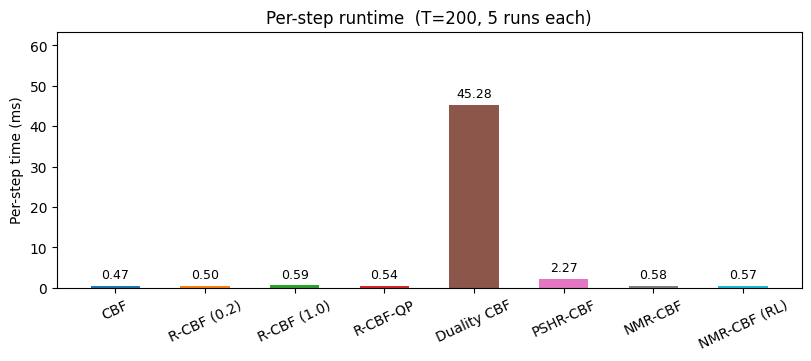

In [17]:
import time

for _name, _fn in _ALL_ROLLOUTS:
    jax.block_until_ready(_fn(X0_DEMO, BIAS_DEMO))

N_REPEATS = 5
timing = {}
for pol_name, rollout_fn in _ALL_ROLLOUTS:
    times = []
    for _ in range(N_REPEATS):
        t0 = time.perf_counter()
        jax.block_until_ready(rollout_fn(X0_DEMO, BIAS_DEMO))
        times.append(time.perf_counter() - t0)
    timing[pol_name] = times
    print(f'  {pol_name:<14}  {np.mean(times)*1e3:.1f} ms ± {np.std(times)*1e3:.1f} ms'
          f'  ({np.mean(times)/T*1e3:.3f} ms/step)')

names    = list(timing.keys())
per_step = [1e3 * np.mean(v) / T for v in timing.values()]
colors   = plt.cm.tab10(np.linspace(0, 0.9, len(names)))

fig, ax = plt.subplots(figsize=(8, 3.5), layout='constrained')
bars = ax.bar(names, per_step, color=colors, width=0.55)
ax.bar_label(bars, labels=[f'{v:.2f}' for v in per_step], padding=3, fontsize=9)
ax.set(ylabel='Per-step time (ms)', ylim=(0, max(per_step) * 1.4),
       title=f'Per-step runtime  (T={T}, {N_REPEATS} runs each)')
ax.tick_params(axis='x', labelrotation=25)
plt.show()
